# 🎓 ScoreSense AI – Intelligent Academic Scoring and Recommendation Engine

> **Predict student exam scores from daily lifestyle behaviors and deliver personalized improvement recommendations.**

---

## 📌 Project Overview

| Detail | Info |
|--------|------|
| **Dataset** | 5,000 simulated student records |
| **Target** | Exam Score (0–100) |
| **Features** | Sleep, Study, Mobile Usage, TV, Exercise, Extracurriculars, Friends Time, Family Time, Attendance, Stress Level, Gender |
| **Goal** | Regression + Personalized Recommendations |
| **Stack** | Python · Pandas · NumPy · Matplotlib · Seaborn · Scikit-learn |

## 🗂️ Pipeline
1. Data Generation & Loading
2. Data Preprocessing
3. Exploratory Data Analysis (EDA)
4. Feature Engineering
5. Model Training & Evaluation
6. Prediction System
7. Recommendation Engine
8. Interactive Web Interface (Streamlit)


---
## 📦 Section 1 – Install & Import Libraries

In [1]:
# ── Core libraries ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings, os, pickle
warnings.filterwarnings('ignore')

# ── Scikit-learn ─────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                              r2_score, mean_absolute_percentage_error)
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                               ExtraTreesRegressor)
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.inspection import permutation_importance

# ── Plot style ────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (10, 5),
                     'axes.titleweight': 'bold'})

SEED = 42
np.random.seed(SEED)
print('✅ Libraries loaded successfully!')

✅ Libraries loaded successfully!


---
## 📊 Section 2 – Dataset Generation

We simulate **5 000 student records** using research-backed distributions for each lifestyle factor.

In [2]:
def generate_dataset(n=5000, seed=42):
    """Generate a realistic student lifestyle & exam-score dataset."""
    rng = np.random.default_rng(seed)

    # ── Raw lifestyle features ────────────────────────────────────────────────
    sleep_hours          = rng.normal(7.0, 1.2, n).clip(3, 12)
    study_hours          = rng.normal(4.5, 1.5, n).clip(0, 12)
    mobile_usage_hours   = rng.normal(3.5, 1.3, n).clip(0, 10)
    tv_hours             = rng.normal(2.0, 1.0, n).clip(0, 8)
    exercise_hours       = rng.normal(1.5, 0.8, n).clip(0, 5)
    extracurricular_hrs  = rng.normal(1.2, 0.7, n).clip(0, 5)
    friends_time_hrs     = rng.normal(2.5, 1.0, n).clip(0, 8)
    family_time_hrs      = rng.normal(2.0, 0.9, n).clip(0, 8)
    attendance_pct       = rng.normal(78, 12, n).clip(40, 100)
    stress_level         = rng.integers(1, 11, n)          # 1–10 scale
    gender               = rng.choice(['Male', 'Female'], n, p=[0.50, 0.50])

    # ── Score formula (research-aligned weights) ──────────────────────────────
    score = (
          8.0  * study_hours
        + 3.5  * sleep_hours
        + 0.35 * attendance_pct
        + 2.5  * exercise_hours
        + 1.5  * extracurricular_hrs
        + 0.8  * family_time_hrs
        - 3.0  * mobile_usage_hours
        - 2.0  * tv_hours
        - 2.5  * stress_level
        - 1.0  * friends_time_hrs
        + rng.normal(0, 5, n)   # noise
        - 10                    # baseline offset
    )

    # Normalise to [30, 100]
    score = ((score - score.min()) / (score.max() - score.min())) * 70 + 30

    df = pd.DataFrame({
        'sleep_hours':         sleep_hours.round(2),
        'study_hours':         study_hours.round(2),
        'mobile_usage_hours':  mobile_usage_hours.round(2),
        'tv_hours':            tv_hours.round(2),
        'exercise_hours':      exercise_hours.round(2),
        'extracurricular_hrs': extracurricular_hrs.round(2),
        'friends_time_hrs':    friends_time_hrs.round(2),
        'family_time_hrs':     family_time_hrs.round(2),
        'attendance_pct':      attendance_pct.round(1),
        'stress_level':        stress_level,
        'gender':              gender,
        'exam_score':          score.round(2)
    })
    return df

df = generate_dataset()
df.to_csv('student_lifestyle_data.csv', index=False)
print(f'✅ Dataset generated: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head(10)

✅ Dataset generated: 5,000 rows × 12 columns


,sleep_hours,study_hours,mobile_usage_hours,tv_hours,exercise_hours,extracurricular_hrs,friends_time_hrs,family_time_hrs,attendance_pct,stress_level,gender,exam_score
0,7.37,4.11,3.73,2.93,0.17,1.25,1.49,1.43,67.2,8,Female,51.16
1,5.75,4.05,4.67,2.96,2.21,0.67,2.45,2.10,62.9,6,Female,49.60
2,7.90,3.46,1.59,2.75,1.45,1.20,1.15,2.11,82.0,9,Female,57.36
3,8.13,5.14,3.13,2.44,1.02,1.03,1.78,2.13,79.8,2,Female,76.70
4,4.66,4.85,4.58,2.41,1.30,2.17,2.26,2.30,51.3,1,Female,58.57
5,5.44,2.11,3.59,2.28,2.33,1.17,2.08,1.07,62.4,3,Female,48.09
6,7.15,2.02,5.41,2.41,2.08,0.23,3.23,3.36,81.1,1,Female,57.41
7,6.62,5.14,1.45,2.48,1.40,1.55,1.76,1.82,77.1,9,Female,64.40
8,6.98,3.28,1.30,0.60,0.59,2.45,0.03,2.27,73.2,6,Male,68.19
9,5.98,4.95,4.50,1.21,0.65,2.04,0.81,1.41,85.3,5,Female,67.48


---
## 🔍 Section 3 – Data Loading & Initial Inspection

In [3]:
print('='*60)
print('            DATASET OVERVIEW')
print('='*60)
print(f'Shape       : {df.shape}')
print(f'Memory      : {df.memory_usage(deep=True).sum()/1024:.1f} KB')
print()
print('Dtypes:')
print(df.dtypes)
print()
print('Missing values:')
print(df.isnull().sum())

            DATASET OVERVIEW
Shape       : (5000, 12)
Memory      : 732.6 KB

Dtypes:
sleep_hours            float64
study_hours            float64
mobile_usage_hours     float64
tv_hours               float64
exercise_hours         float64
extracurricular_hrs    float64
friends_time_hrs       float64
family_time_hrs        float64
attendance_pct         float64
stress_level             int64
gender                  object
exam_score             float64
dtype: object

Missing values:
sleep_hours            0
study_hours            0
mobile_usage_hours     0
tv_hours               0
exercise_hours         0
extracurricular_hrs    0
friends_time_hrs       0
family_time_hrs        0
attendance_pct         0
stress_level           0
gender                 0
exam_score             0
dtype: int64


In [4]:
print('Statistical Summary – Numerical Features')
df.describe().round(2)

Statistical Summary – Numerical Features


,sleep_hours,study_hours,mobile_usage_hours,tv_hours,exercise_hours,extracurricular_hrs,friends_time_hrs,family_time_hrs,attendance_pct,stress_level,exam_score
count,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00
mean,6.98,4.50,3.49,2.06,1.53,1.22,2.51,1.99,77.78,5.44,63.00
std,1.20,1.52,1.29,0.99,0.77,0.68,0.99,0.90,11.62,2.87,9.52
min,3.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,40.00,1.00,30.00
25%,6.17,3.51,2.62,1.36,0.99,0.72,1.83,1.38,69.97,3.00,56.73
50%,7.00,4.47,3.46,2.05,1.52,1.21,2.50,1.98,77.90,5.00,63.01
75%,7.76,5.51,4.36,2.73,2.04,1.69,3.18,2.59,86.00,8.00,69.17
max,11.14,10.54,8.90,5.20,4.35,3.78,6.59,5.89,100.00,10.00,100.00


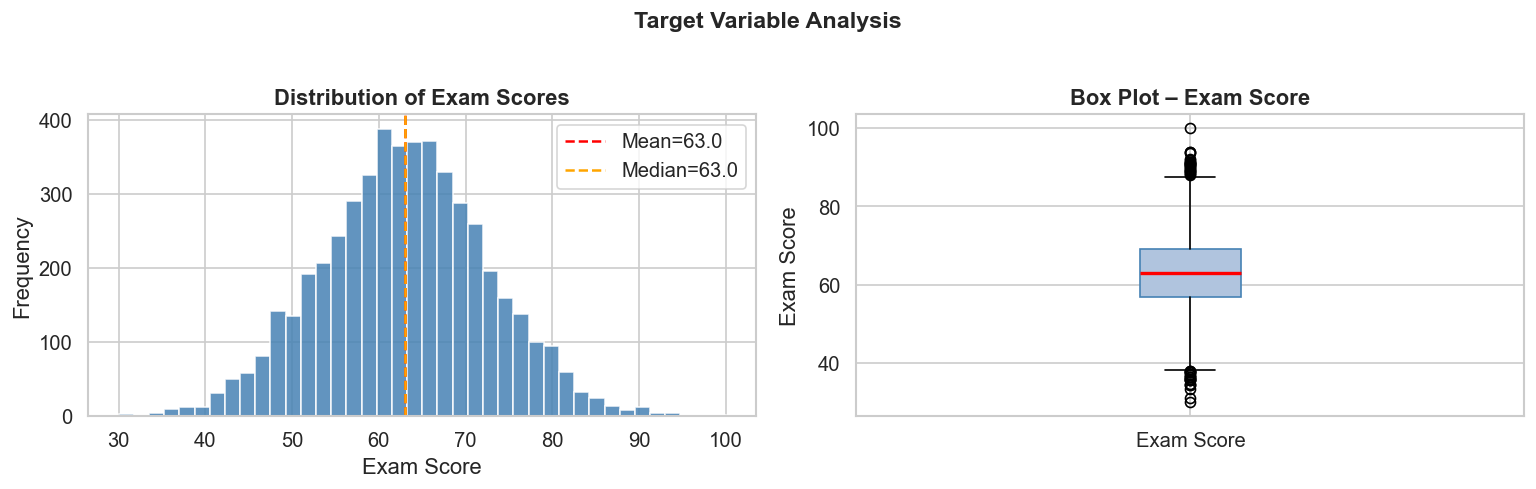

Skewness: 0.006  |  Kurtosis: -0.007


In [5]:
# Target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['exam_score'], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(df['exam_score'].mean(), color='red', linestyle='--', label=f"Mean={df['exam_score'].mean():.1f}")
axes[0].axvline(df['exam_score'].median(), color='orange', linestyle='--', label=f"Median={df['exam_score'].median():.1f}")
axes[0].set_title('Distribution of Exam Scores')
axes[0].set_xlabel('Exam Score')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].boxplot(df['exam_score'], patch_artist=True,
                boxprops=dict(facecolor='lightsteelblue', color='steelblue'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Box Plot – Exam Score')
axes[1].set_ylabel('Exam Score')
axes[1].set_xticks([1], ['Exam Score'])

plt.suptitle('Target Variable Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_target_distribution.png', bbox_inches='tight')
plt.show()
print(f"Skewness: {df['exam_score'].skew():.3f}  |  Kurtosis: {df['exam_score'].kurt():.3f}")

---
## 🛠️ Section 4 – Data Preprocessing

In [6]:
# =============================================================
# SECTION 4 - DATA PREPROCESSING
# Changes applied per project requirements:
#   1. Mobile + TV      --> merged as 'screen_time'   (total)
#   2. Exercise + Extra --> merged as 'active_time'   (total)
#   3. Friends + Family --> merged as 'social_time'   (total)
#   4. Stress (1-10)    --> binary 'stressed' (Yes/No -> 1/0)
#   5. Gender           --> label-encoded (Female=0, Male=1)
#   6. Grade category   --> derived from exam_score
#   7. Outlier report   --> IQR method on merged columns
# =============================================================

df_processed = df.copy()

# ── 1. Merge Screen Time: Mobile + TV ----------------------------------------
df_processed['screen_time'] = (
    df_processed['mobile_usage_hours'] + df_processed['tv_hours']
).round(2)
# Keep originals for EDA reference but drop before modelling
print(f'screen_time range : {df_processed["screen_time"].min():.1f} - {df_processed["screen_time"].max():.1f} hrs')

# ── 2. Merge Active Time: Exercise + Extracurricular -------------------------
df_processed['active_time'] = (
    df_processed['exercise_hours'] + df_processed['extracurricular_hrs']
).round(2)
print(f'active_time range : {df_processed["active_time"].min():.1f} - {df_processed["active_time"].max():.1f} hrs')

# ── 3. Merge Social Time: Friends + Family ------------------------------------
df_processed['social_time'] = (
    df_processed['friends_time_hrs'] + df_processed['family_time_hrs']
).round(2)
print(f'social_time range : {df_processed["social_time"].min():.1f} - {df_processed["social_time"].max():.1f} hrs')

# ── 4. Stress: numeric (1-10) --> binary Yes/No -> 1/0 -----------------------
# Threshold: stress_level >= 6 is considered 'stressed'
df_processed['stressed'] = (df_processed['stress_level'] >= 6).astype(int)
stress_pct = df_processed['stressed'].mean() * 100
print(f'stressed=1 (Yes) : {stress_pct:.1f}%  |  stressed=0 (No) : {100-stress_pct:.1f}%')

# ── 5. Gender: encode --------------------------------------------------------
le = LabelEncoder()
df_processed['gender_encoded'] = le.fit_transform(df_processed['gender'])  # Female=0, Male=1
print(f'gender encoded    : {dict(zip(le.classes_, le.transform(le.classes_)))}')

# ── 6. Grade category --------------------------------------------------------
def grade_category(score):
    if score >= 85:   return 'A (Excellent)'
    elif score >= 70: return 'B (Good)'
    elif score >= 55: return 'C (Average)'
    elif score >= 40: return 'D (Below Avg)'
    else:             return 'F (Fail)'

df_processed['grade'] = df_processed['exam_score'].apply(grade_category)

# ── 7. Outlier report (IQR) on final merged columns --------------------------
num_cols = [
    'sleep_hours', 'study_hours', 'screen_time',
    'active_time', 'social_time', 'attendance_pct', 'exam_score'
]
outlier_counts = {}
for col in num_cols:
    Q1, Q3 = df_processed[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    n_out = ((df_processed[col] < Q1 - 1.5*IQR) |
             (df_processed[col] > Q3 + 1.5*IQR)).sum()
    outlier_counts[col] = n_out

print('\nOutlier Count per Feature (IQR method):')
print(pd.Series(outlier_counts, name='Outliers').sort_values(ascending=False))

# ── 8. Show processed column summary -----------------------------------------
print('\nProcessed Dataset Columns:')
display_cols = ['sleep_hours','study_hours','screen_time','active_time',
                'social_time','attendance_pct','stressed','gender_encoded',
                'exam_score','grade']
print(df_processed[display_cols].head(8).to_string(index=False))

screen_time range : 0.5 - 11.4 hrs
active_time range : 0.0 - 6.6 hrs
social_time range : 0.3 - 9.6 hrs
stressed=1 (Yes) : 49.3%  |  stressed=0 (No) : 50.7%
gender encoded    : {'Female': np.int64(0), 'Male': np.int64(1)}

Outlier Count per Feature (IQR method):
sleep_hours       48
study_hours       48
exam_score        46
screen_time       34
social_time       28
attendance_pct    22
active_time       19
Name: Outliers, dtype: int64

Processed Dataset Columns:
 sleep_hours  study_hours  screen_time  active_time  social_time  attendance_pct  stressed  gender_encoded  exam_score         grade
        7.37         4.11         6.66         1.42         2.92            67.2         1               0       51.16 D (Below Avg)
        5.75         4.05         7.63         2.88         4.55            62.9         1               0       49.60 D (Below Avg)
        7.90         3.46         4.34         2.65         3.26            82.0         1               0       57.36   C (Average)
  

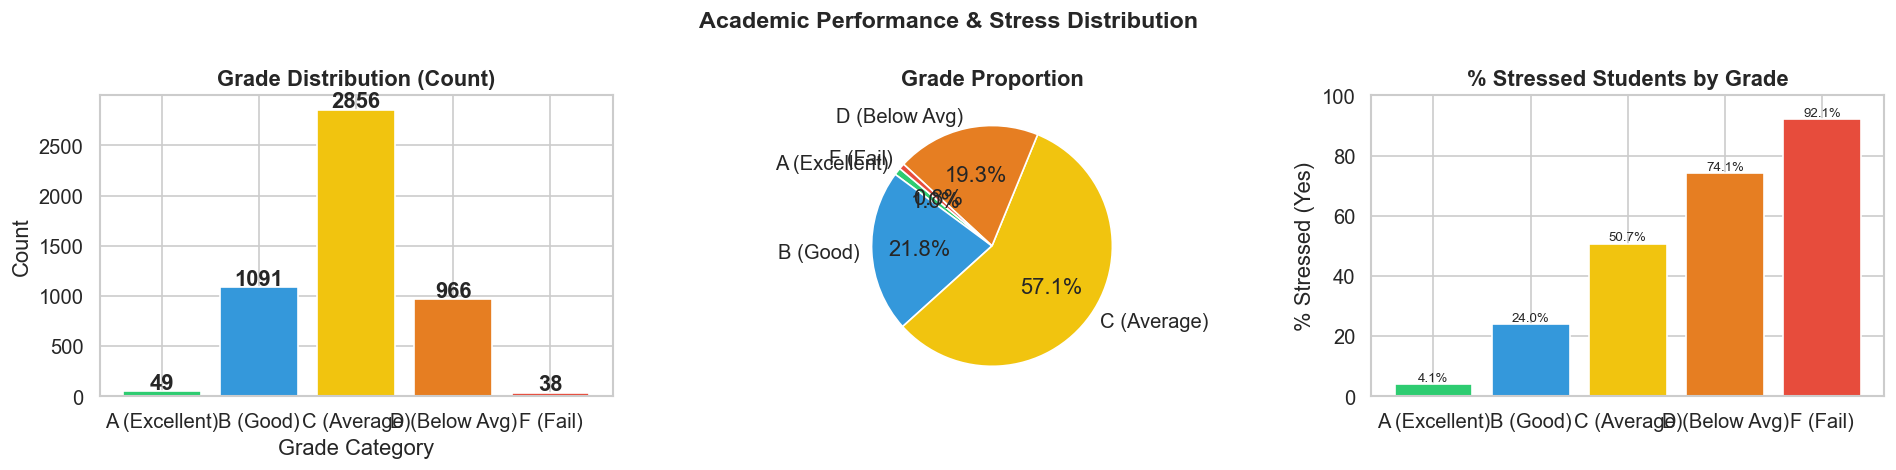

In [7]:
# Grade distribution
grade_order  = ['A (Excellent)','B (Good)','C (Average)','D (Below Avg)','F (Fail)']
grade_colors = ['#2ecc71','#3498db','#f1c40f','#e67e22','#e74c3c']

grade_counts = df_processed['grade'].value_counts().reindex(grade_order)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Bar chart
axes[0].bar(grade_order, grade_counts, color=grade_colors, edgecolor='white')
axes[0].set_title('Grade Distribution (Count)')
axes[0].set_xlabel('Grade Category')
axes[0].set_ylabel('Count')
for i, v in enumerate(grade_counts):
    axes[0].text(i, v+20, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(grade_counts, labels=grade_order, colors=grade_colors,
            autopct='%1.1f%%', startangle=140)
axes[1].set_title('Grade Proportion')

# Stressed vs Not Stressed by grade
stress_grade = df_processed.groupby('grade')['stressed'].mean() * 100
stress_grade = stress_grade.reindex(grade_order)
axes[2].bar(grade_order, stress_grade, color=grade_colors, edgecolor='white')
axes[2].set_title('% Stressed Students by Grade')
axes[2].set_ylabel('% Stressed (Yes)')
axes[2].set_ylim(0, 100)
for i, v in enumerate(stress_grade):
    axes[2].text(i, v+1, f'{v:.1f}%', ha='center', fontsize=8)

plt.suptitle('Academic Performance & Stress Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_grade_distribution.png', bbox_inches='tight')
plt.show()


---
## 📈 Section 5 – Exploratory Data Analysis (EDA)

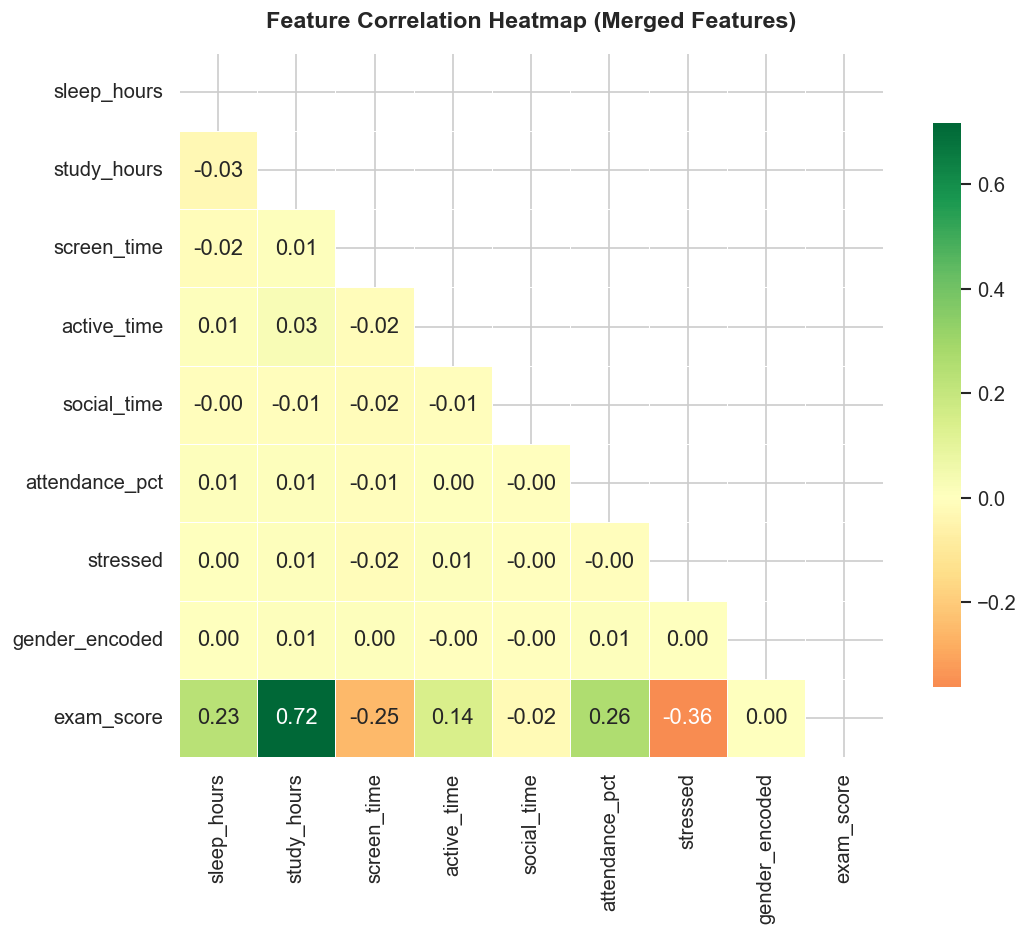

Feature correlations with Exam Score (merged):
study_hours       0.717
stressed         -0.362
attendance_pct    0.259
screen_time      -0.253
sleep_hours       0.232
active_time       0.142
social_time      -0.022
gender_encoded    0.003


In [8]:
# Correlation heatmap using MERGED feature set
corr_cols = ['sleep_hours','study_hours','screen_time','active_time',
             'social_time','attendance_pct','stressed','gender_encoded','exam_score']
corr_matrix = df_processed[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Feature Correlation Heatmap (Merged Features)', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('plot_correlation_heatmap.png', bbox_inches='tight')
plt.show()

# Top correlations with exam_score
score_corr = corr_matrix['exam_score'].drop('exam_score').sort_values(key=abs, ascending=False)
print('Feature correlations with Exam Score (merged):')
print(score_corr.round(3).to_string())


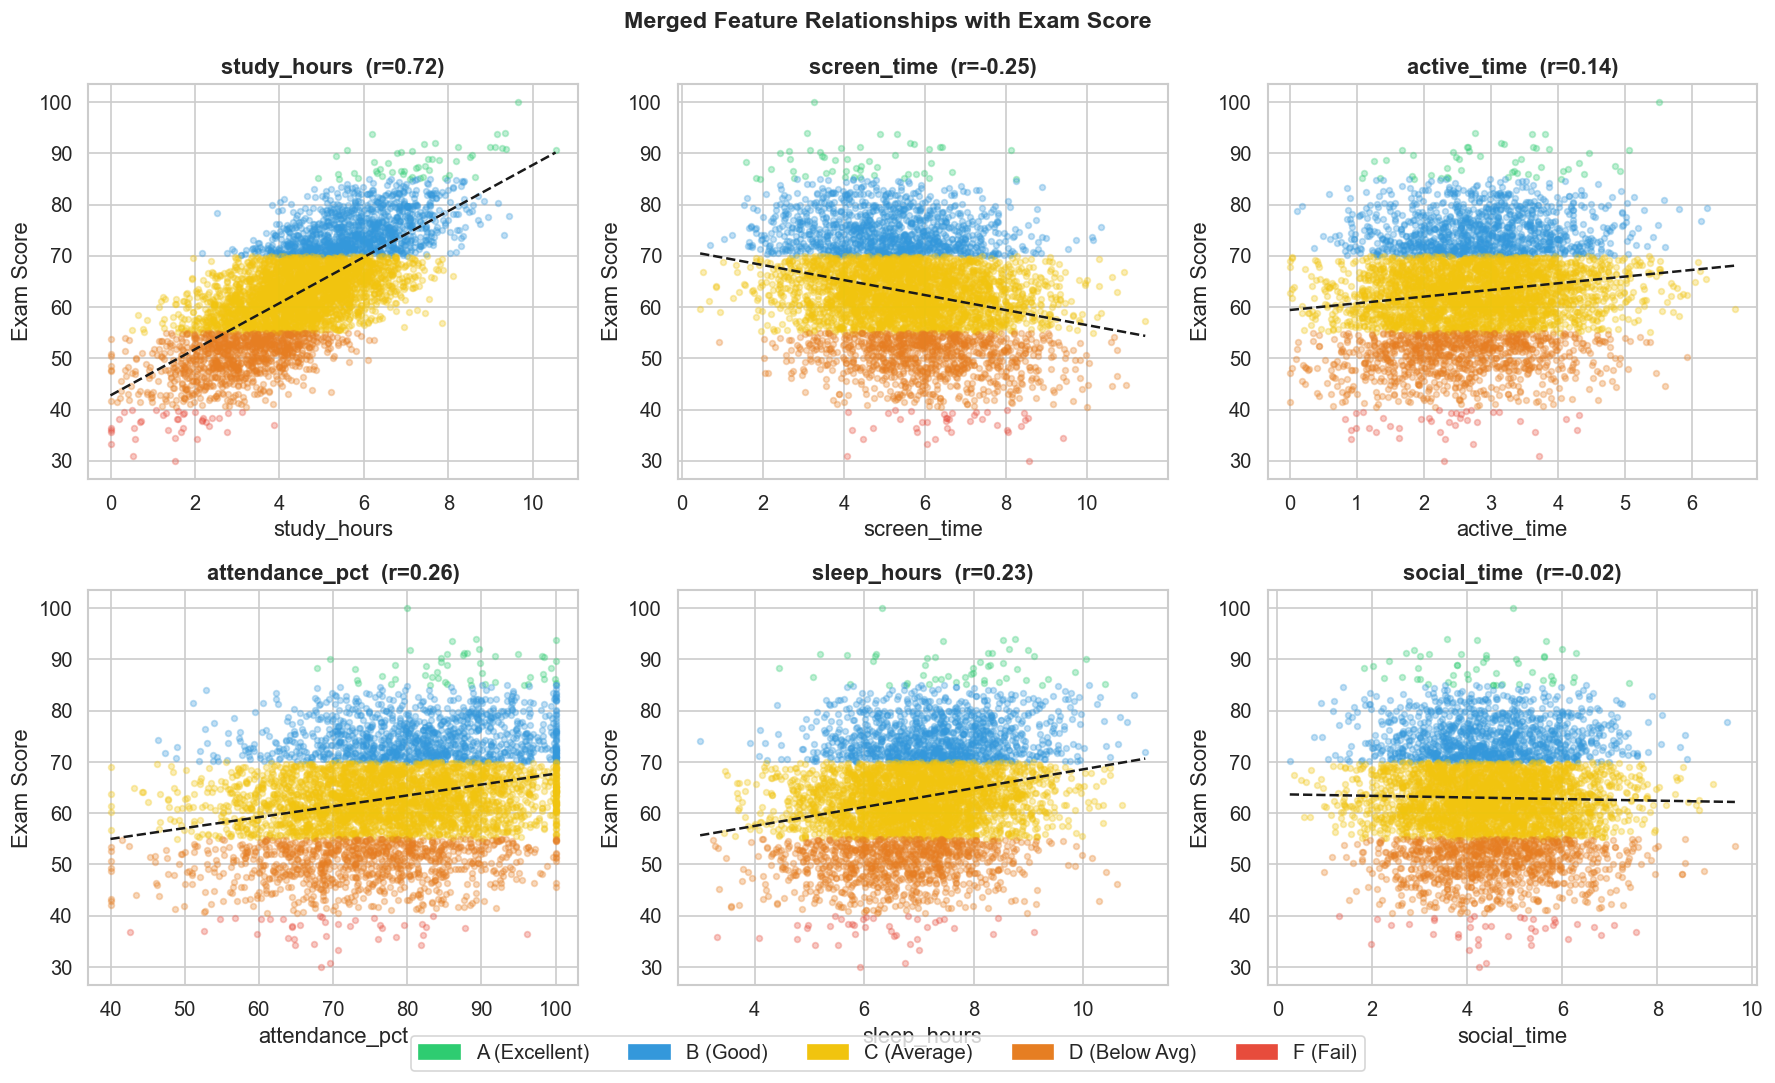

In [9]:
# Scatter plots: top features vs exam score (using merged features)
merged_features = ['study_hours','screen_time','active_time',
                   'attendance_pct','sleep_hours','social_time']
colors_map = {'A (Excellent)':'#2ecc71','B (Good)':'#3498db',
              'C (Average)':'#f1c40f','D (Below Avg)':'#e67e22','F (Fail)':'#e74c3c'}

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, feat in enumerate(merged_features):
    for grade, grp in df_processed.groupby('grade'):
        axes[i].scatter(grp[feat], grp['exam_score'],
                        c=colors_map[grade], alpha=0.3, s=12, label=grade)
    m, b = np.polyfit(df_processed[feat], df_processed['exam_score'], 1)
    x_line = np.linspace(df_processed[feat].min(), df_processed[feat].max(), 100)
    axes[i].plot(x_line, m*x_line+b, 'k--', linewidth=1.5, label='Trend')
    r = df_processed[[feat,'exam_score']].corr().iloc[0,1]
    axes[i].set_title(f'{feat}  (r={r:.2f})')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Exam Score')

handles = [mpatches.Patch(color=c, label=g) for g, c in colors_map.items()]
fig.legend(handles=handles, loc='lower center', ncol=5, bbox_to_anchor=(0.5, -0.01))
plt.suptitle('Merged Feature Relationships with Exam Score', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_scatter_top_features.png', bbox_inches='tight')
plt.show()


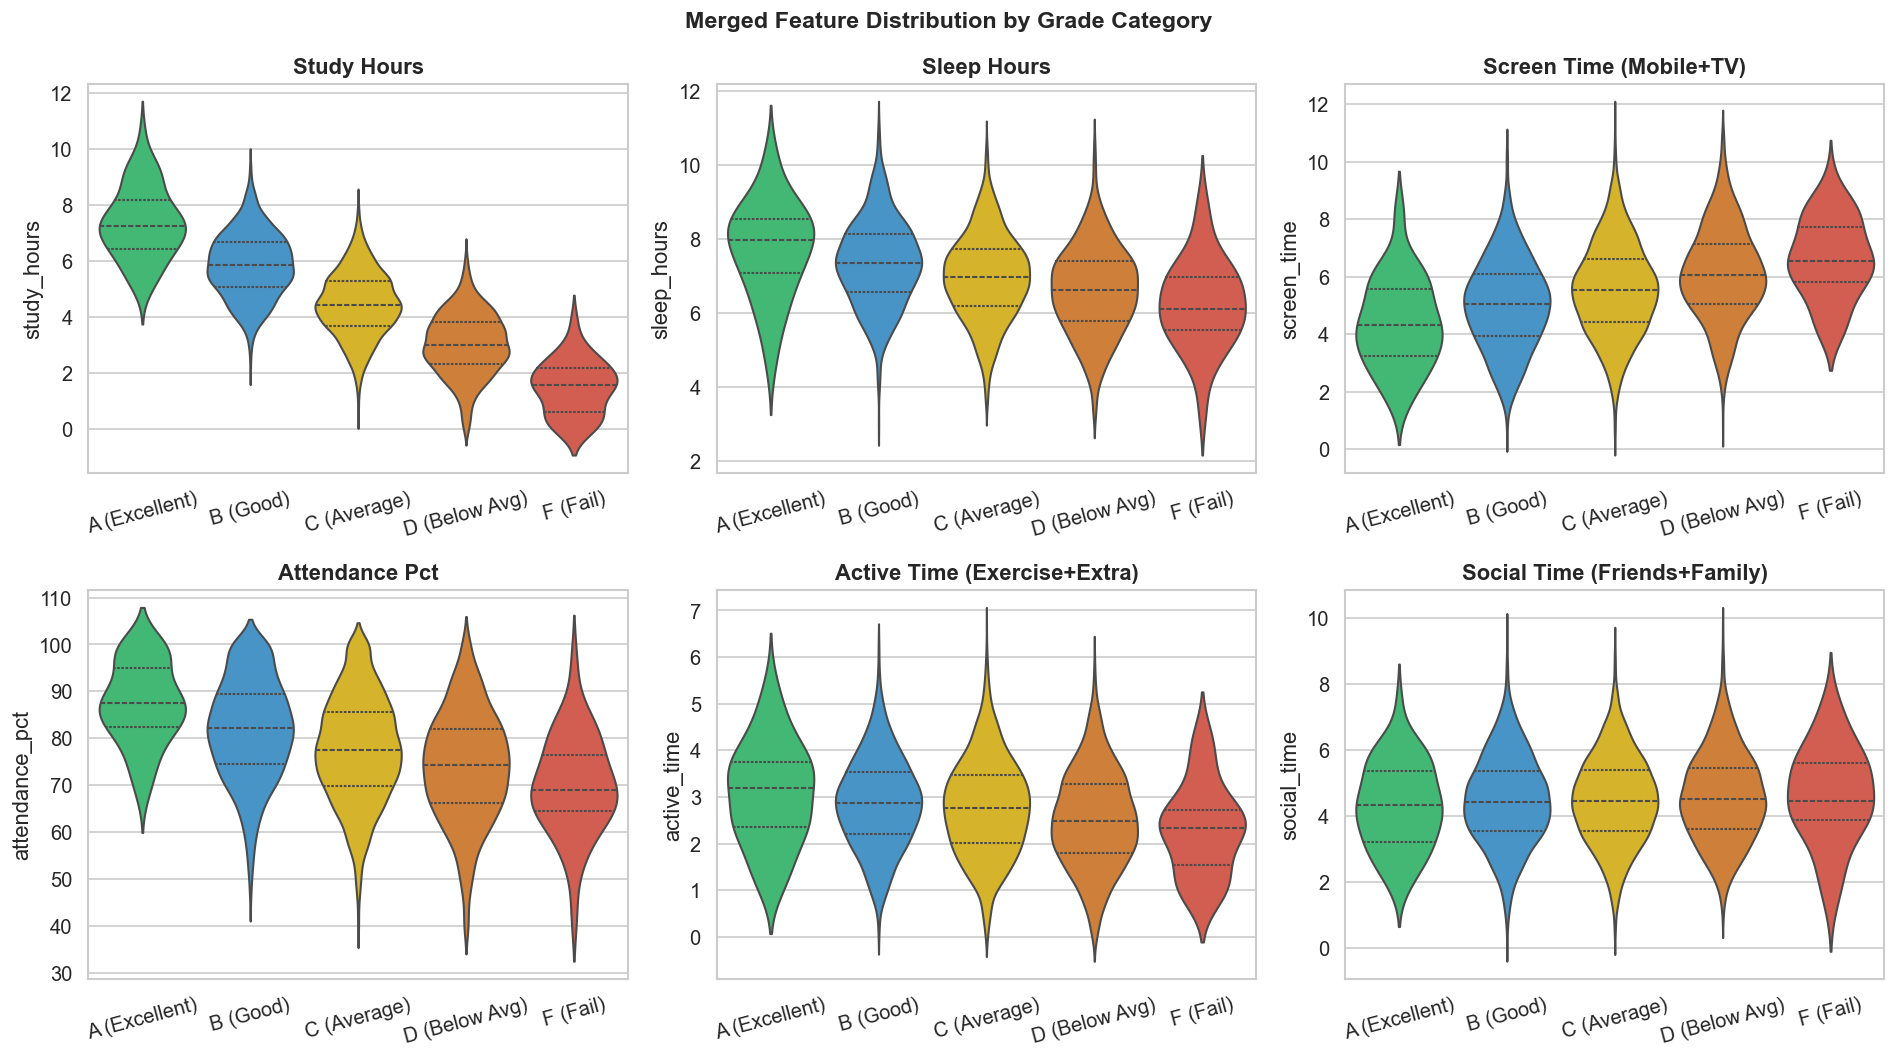

In [10]:
# Violin plots using merged features
plot_features = ['study_hours','sleep_hours','screen_time',
                 'attendance_pct','active_time','social_time']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, feat in enumerate(plot_features):
    sns.violinplot(data=df_processed, x='grade', y=feat,
                   order=grade_order, palette=grade_colors,
                   inner='quartile', ax=axes[i])
    label = feat.replace('_',' ').title()
    if feat == 'screen_time':  label = 'Screen Time (Mobile+TV)'
    if feat == 'active_time':  label = 'Active Time (Exercise+Extra)'
    if feat == 'social_time':  label = 'Social Time (Friends+Family)'
    axes[i].set_title(label)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=15)

plt.suptitle('Merged Feature Distribution by Grade Category', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_violin_by_grade.png', bbox_inches='tight')
plt.show()


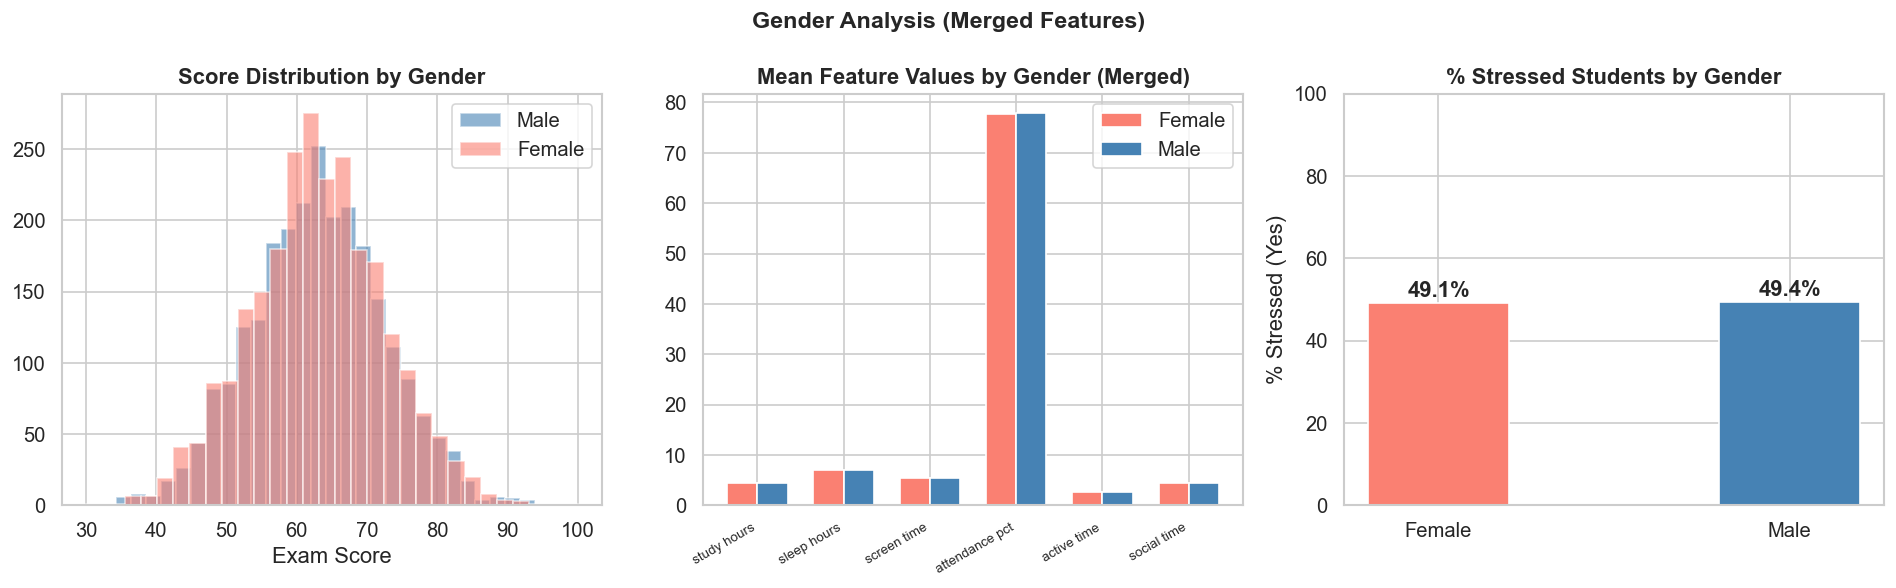

Mean Exam Score by Gender:
         mean   std  count
gender                    
Female  62.98  9.52   2504
Male    63.02  9.52   2496


In [11]:
# Gender analysis using merged features
plot_features = ['study_hours','sleep_hours','screen_time',
                 'attendance_pct','active_time','social_time']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Score distribution by gender
for gender, color in [('Male','steelblue'), ('Female','salmon')]:
    subset = df_processed[df_processed['gender']==gender]['exam_score']
    axes[0].hist(subset, bins=30, alpha=0.6, label=gender, color=color, edgecolor='white')
axes[0].set_title('Score Distribution by Gender')
axes[0].set_xlabel('Exam Score')
axes[0].legend()

# Mean scores per merged feature by gender
gender_means = df_processed.groupby('gender')[plot_features].mean().T
x = np.arange(len(gender_means))
w = 0.35
axes[1].bar(x-w/2, gender_means['Female'], w, label='Female', color='salmon')
axes[1].bar(x+w/2, gender_means['Male'],   w, label='Male',   color='steelblue')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f.replace('_',' ') for f in gender_means.index],
                         rotation=30, ha='right', fontsize=8)
axes[1].set_title('Mean Feature Values by Gender (Merged)')
axes[1].legend()

# Stressed distribution by gender
stress_gender = df_processed.groupby('gender')['stressed'].mean() * 100
axes[2].bar(stress_gender.index, stress_gender.values,
            color=['salmon','steelblue'], edgecolor='white', width=0.4)
axes[2].set_title('% Stressed Students by Gender')
axes[2].set_ylabel('% Stressed (Yes)')
axes[2].set_ylim(0, 100)
for i, (g, v) in enumerate(stress_gender.items()):
    axes[2].text(i, v+1.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.suptitle('Gender Analysis (Merged Features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_gender_analysis.png', bbox_inches='tight')
plt.show()

print('Mean Exam Score by Gender:')
print(df_processed.groupby('gender')['exam_score'].agg(['mean','std','count']).round(2))


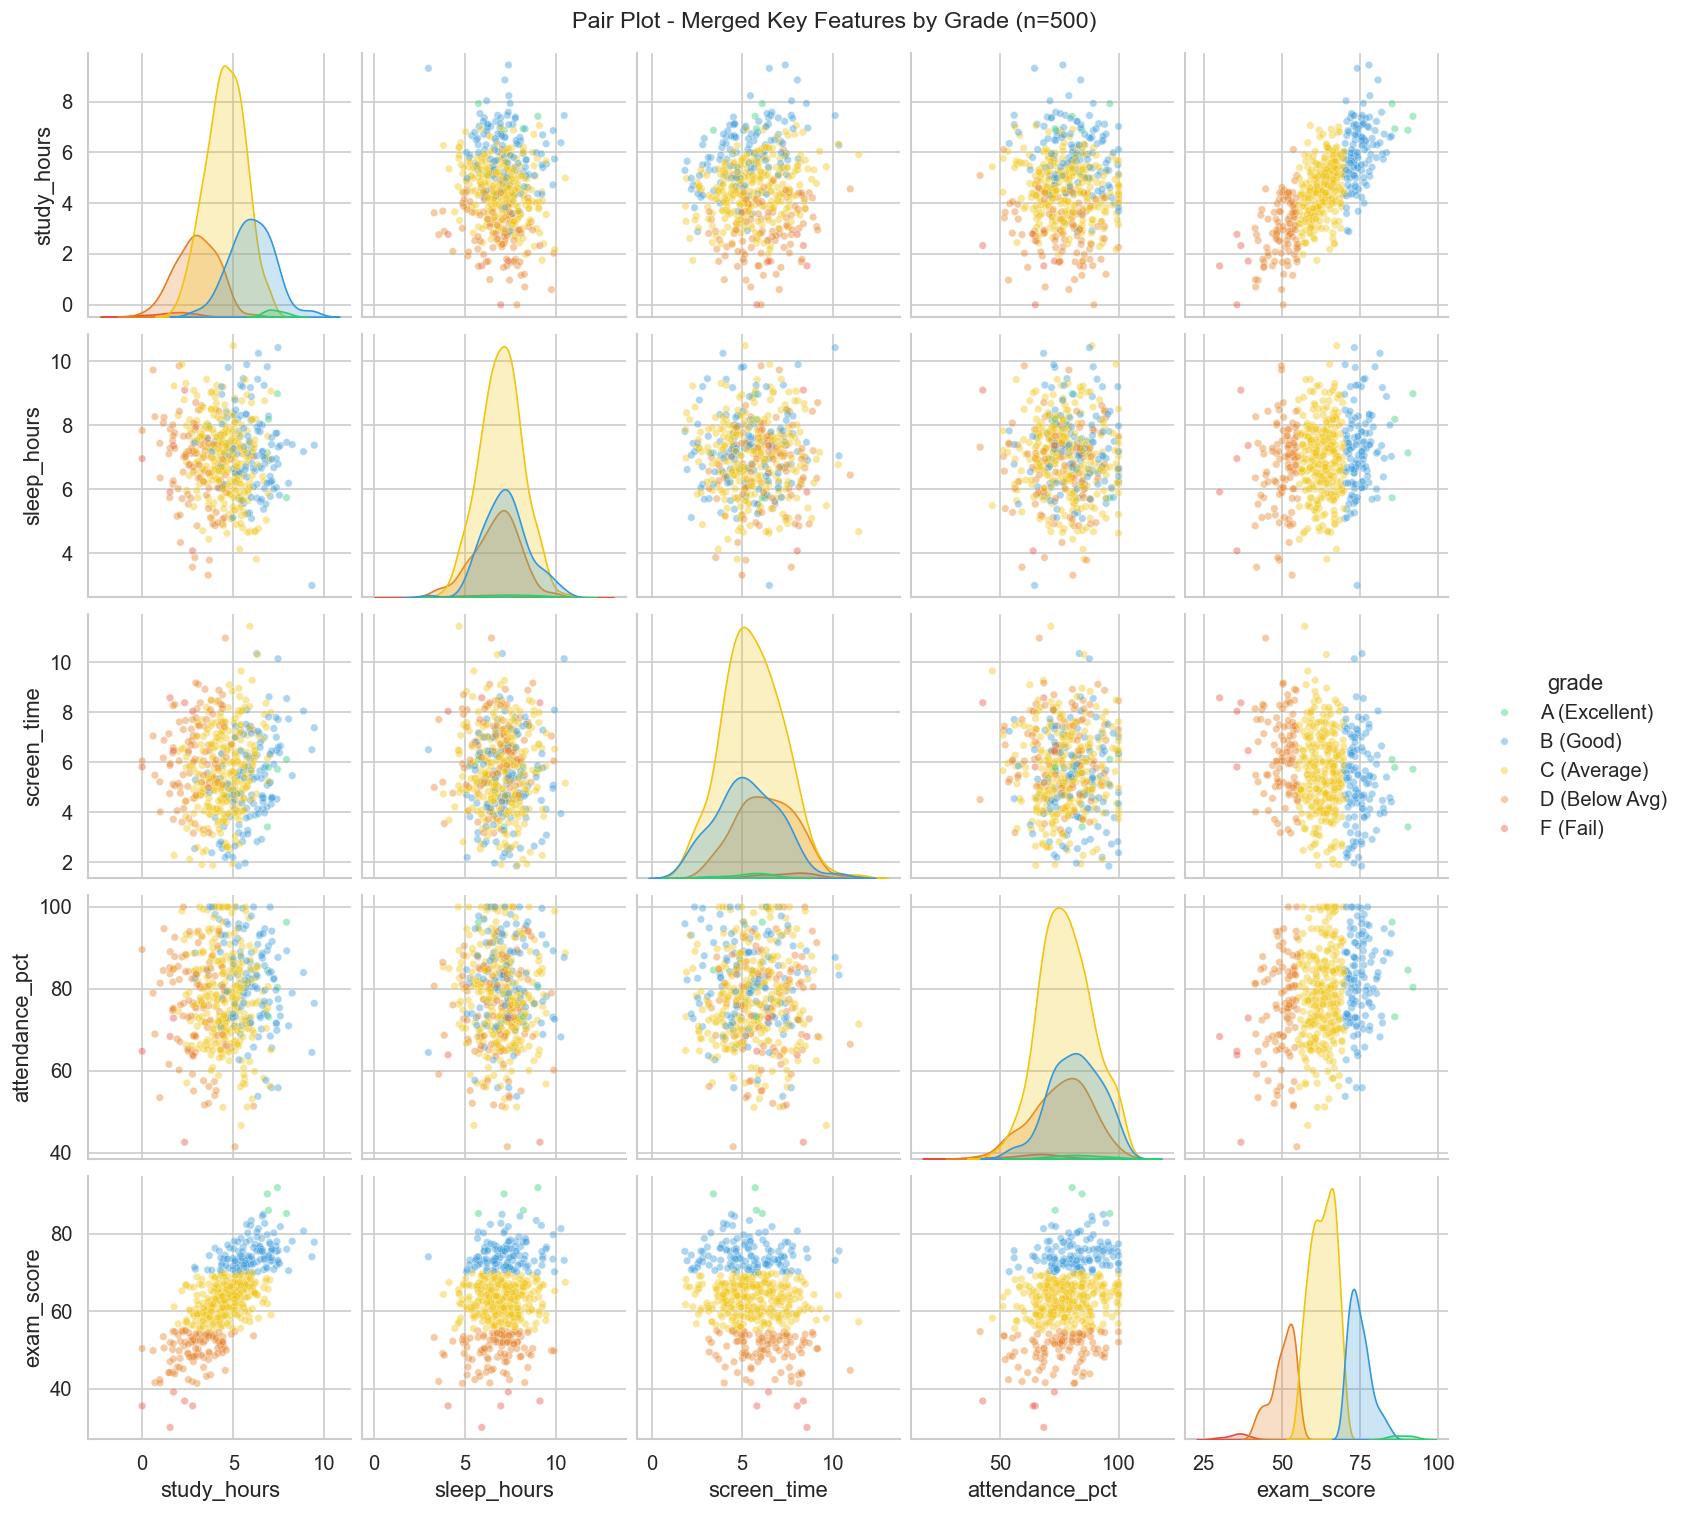

In [12]:
# Pair plot using merged features (n=500 sample)
sample_df = df_processed.sample(500, random_state=SEED)
pair_features = ['study_hours','sleep_hours','screen_time','attendance_pct','exam_score']

g = sns.pairplot(sample_df[pair_features + ['grade']],
                 hue='grade', hue_order=grade_order,
                 palette=dict(zip(grade_order, grade_colors)),
                 diag_kind='kde', plot_kws={'alpha':0.4, 's':20})
g.fig.suptitle('Pair Plot - Merged Key Features by Grade (n=500)',
               fontsize=14, y=1.01)
plt.savefig('plot_pairplot.png', bbox_inches='tight')
plt.show()


---
## ⚙️ Section 6 – Feature Engineering

In [13]:
df_model = df_processed.copy()

# FEATURES now use MERGED columns from preprocessing:
#   screen_time  = mobile_usage_hours + tv_hours
#   active_time  = exercise_hours     + extracurricular_hrs
#   social_time  = friends_time_hrs   + family_time_hrs
#   stressed     = 1 if stress_level >= 6 else 0

# ── Engineered features (built on top of merged columns) ----------------------
# 1. Study efficiency: study relative to distraction
df_model['study_efficiency']   = df_model['study_hours'] / (df_model['screen_time'] + 1)

# 2. Health score composite (uses original sub-cols still present in df)
df_model['health_score']       = (
    df_model['sleep_hours'] / 8
    + df_model['exercise_hours'] / 2
    - df_model['stressed'] * 0.4   # stressed binary penalises health score
) / 3 * 100

# 3. Sleep adequacy flag
df_model['sleep_adequate']     = (df_model['sleep_hours'] >= 7).astype(int)

# 4. High screen time flag
df_model['high_screen']        = (df_model['screen_time'] > 5).astype(int)

# 5. Interaction: study x attendance
df_model['study_x_attendance'] = df_model['study_hours'] * df_model['attendance_pct'] / 100

# 6. Stress-adjusted study (stressed=1 reduces effective study)
df_model['stress_adj_study']   = df_model['study_hours'] * (1 - df_model['stressed'] * 0.25)

# ── Final feature set ---------------------------------------------------------
FEATURES = [
    # Merged lifestyle features (8 inputs -> 7 features after merging)
    'sleep_hours', 'study_hours', 'screen_time',
    'active_time', 'social_time', 'attendance_pct',
    'stressed', 'gender_encoded',
    # Engineered
    'study_efficiency', 'health_score', 'sleep_adequate',
    'high_screen', 'study_x_attendance', 'stress_adj_study'
]
TARGET = 'exam_score'

X = df_model[FEATURES]
y = df_model[TARGET]

print(f'Feature matrix shape : {X.shape}')
print(f'\nFinal Features ({len(FEATURES)}):')
for f in FEATURES:
    print(f'  - {f}')
print()
X.describe().round(2)


Feature matrix shape : (5000, 14)

Final Features (14):
  - sleep_hours
  - study_hours
  - screen_time
  - active_time
  - social_time
  - attendance_pct
  - stressed
  - gender_encoded
  - study_efficiency
  - health_score
  - sleep_adequate
  - high_screen
  - study_x_attendance
  - stress_adj_study



,sleep_hours,study_hours,screen_time,active_time,social_time,attendance_pct,stressed,gender_encoded,study_efficiency,health_score,sleep_adequate,high_screen,study_x_attendance,stress_adj_study
count,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.0,5000.00,5000.00,5000.0,5000.00,5000.00,5000.00
mean,6.98,4.50,5.55,2.74,4.49,77.78,0.49,0.5,0.74,47.93,0.5,0.63,3.50,3.94
std,1.20,1.52,1.64,1.03,1.34,11.62,0.50,0.5,0.34,15.24,0.5,0.48,1.31,1.46
min,3.00,0.00,0.45,0.00,0.26,40.00,0.00,0.0,0.00,4.17,0.0,0.00,0.00,0.00
25%,6.17,3.51,4.42,2.00,3.56,69.97,0.00,0.0,0.51,37.32,0.0,0.00,2.60,2.96
50%,7.00,4.47,5.52,2.73,4.46,77.90,0.00,0.0,0.69,47.81,0.5,1.00,3.43,3.87
75%,7.76,5.51,6.63,3.44,5.41,86.00,1.00,1.0,0.91,58.46,1.0,1.00,4.34,4.85
max,11.14,10.54,11.44,6.64,9.63,100.00,1.00,1.0,3.25,101.54,1.0,1.00,10.34,10.54


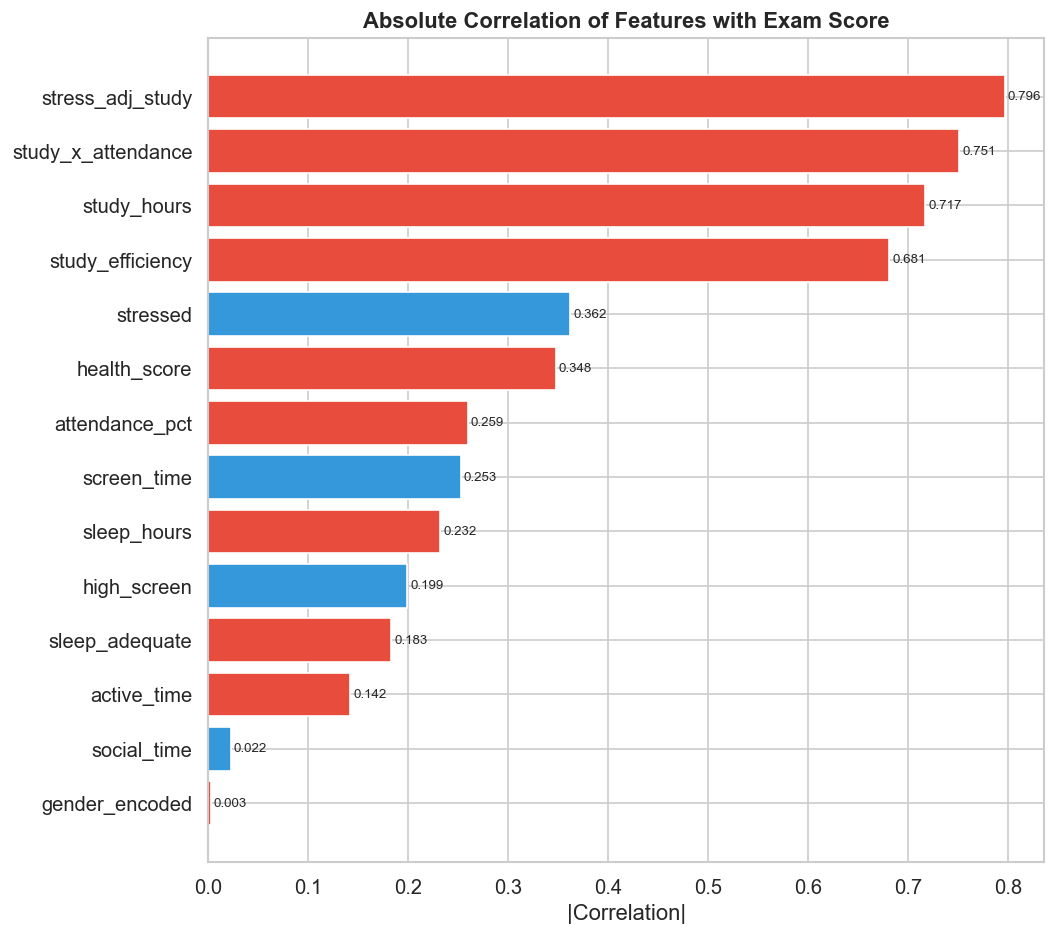

In [14]:
# Quick feature importance via correlation to target
feat_corr = X.corrwith(y).abs().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 8))
colors = ['#e74c3c' if v > 0 else '#3498db'
          for v in X.corrwith(y).reindex(feat_corr.index)]
ax.barh(feat_corr.index, feat_corr.values, color=colors)
ax.set_title('Absolute Correlation of Features with Exam Score')
ax.set_xlabel('|Correlation|')
for i, v in enumerate(feat_corr.values):
    ax.text(v+0.003, i, f'{v:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('plot_feature_correlation.png', bbox_inches='tight')
plt.show()

---
## 🤖 Section 7 – Model Training & Evaluation

In [29]:
# ── Train / Test split ────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED)

print(f'Training set : {X_train.shape[0]:,} samples')
print(f'Testing  set : {X_test.shape[0]:,} samples')

Training set : 4,000 samples
Testing  set : 1,000 samples


In [30]:
# ── Compare 8 baseline models ─────────────────────────────────────────────────
models = {
    'Linear Regression':          LinearRegression(),
    'Ridge Regression':           Ridge(alpha=1.0),
    'Lasso Regression':           Lasso(alpha=0.1),
    'Decision Tree':              DecisionTreeRegressor(max_depth=8, random_state=SEED),
    'Random Forest':              RandomForestRegressor(n_estimators=100, random_state=SEED),
    'Gradient Boosting':          GradientBoostingRegressor(n_estimators=100, random_state=SEED),
    'Extra Trees':                ExtraTreesRegressor(n_estimators=100, random_state=SEED),
    'K-Nearest Neighbors':        KNeighborsRegressor(n_neighbors=7),
}

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

results = []
for name, model in models.items():
    X_tr = X_train_sc if name in ['Linear Regression','Ridge Regression',
                                   'Lasso Regression','K-Nearest Neighbors','SVR'] else X_train
    X_te = X_test_sc  if name in ['Linear Regression','Ridge Regression',
                                   'Lasso Regression','K-Nearest Neighbors','SVR'] else X_test
    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)
    cv = cross_val_score(model, X_tr, y_train, cv=5, scoring='r2')
    results.append({
        'Model':    name,
        'R2':       r2_score(y_test, y_pred),
        'MAE':      mean_absolute_error(y_test, y_pred),
        'RMSE':     np.sqrt(mean_squared_error(y_test, y_pred)),
        'CV_R2':    cv.mean(),
        'CV_Std':   cv.std()
    })
    print(f"  {name:<28} R²={r2_score(y_test,y_pred):.4f}  MAE={mean_absolute_error(y_test,y_pred):.3f}")

results_df = pd.DataFrame(results).sort_values('R2', ascending=False).reset_index(drop=True)
print('\n📊 Model Comparison:')
results_df.round(4)

  Linear Regression            R²=0.8626  MAE=2.863
  Ridge Regression             R²=0.8626  MAE=2.864
  Lasso Regression             R²=0.8590  MAE=2.903
  Decision Tree                R²=0.7340  MAE=3.869
  Random Forest                R²=0.8377  MAE=3.042
  Gradient Boosting            R²=0.8504  MAE=2.941
  Extra Trees                  R²=0.8324  MAE=3.129
  K-Nearest Neighbors          R²=0.8050  MAE=3.379

📊 Model Comparison:


,Model,R2,MAE,RMSE,CV_R2,CV_Std
0,Linear Regression,0.8626,2.8627,3.5706,0.8552,0.0025
1,Ridge Regression,0.8626,2.8638,3.5716,0.8552,0.0025
2,Lasso Regression,0.8590,2.9029,3.6175,0.8532,0.0033
3,Gradient Boosting,0.8504,2.9407,3.7268,0.8367,0.0056
4,Random Forest,0.8377,3.0420,3.8818,0.8227,0.0071
5,Extra Trees,0.8324,3.1286,3.9441,0.8265,0.0045
6,K-Nearest Neighbors,0.8050,3.3786,4.2539,0.7933,0.0081
7,Decision Tree,0.7340,3.8692,4.9690,0.7174,0.0132


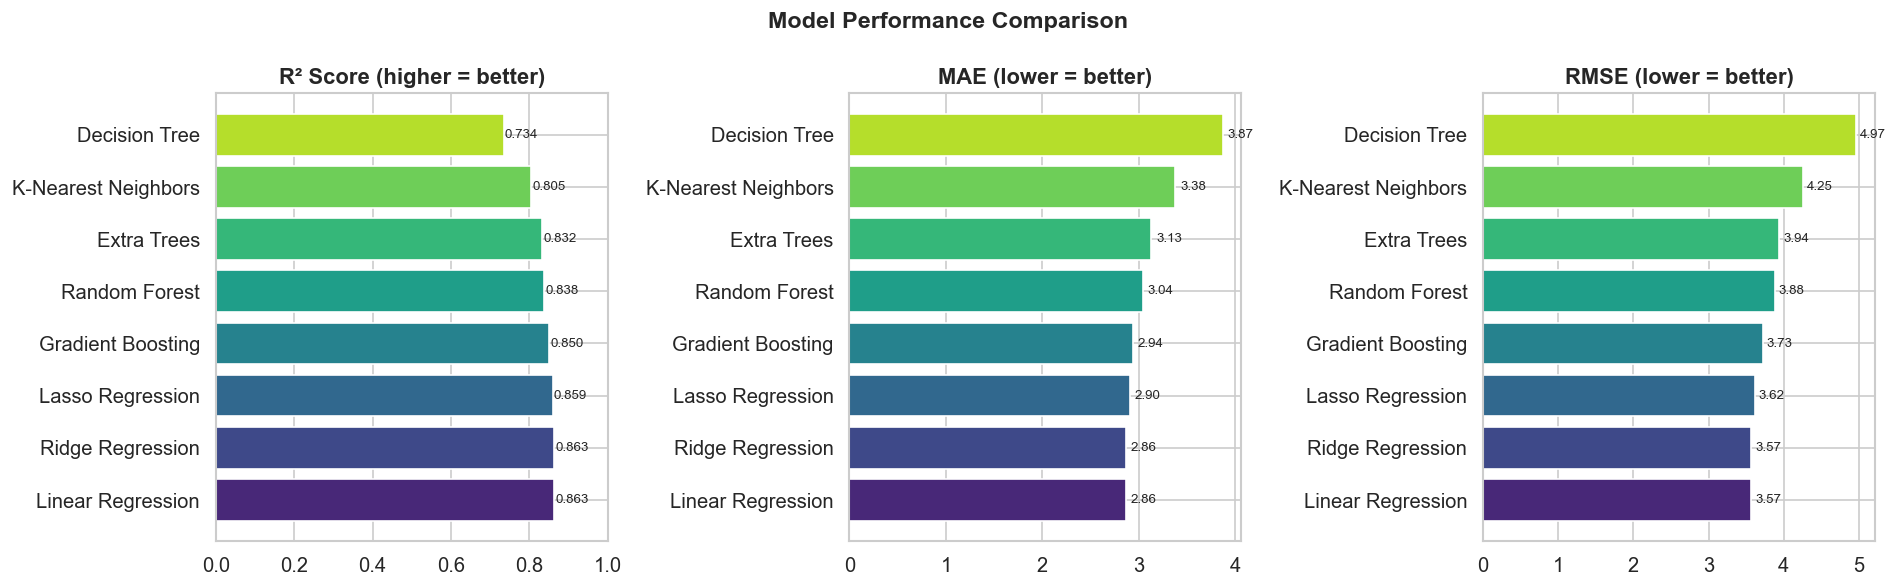

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

bar_kw = dict(edgecolor='white')
palette = sns.color_palette('viridis', len(results_df))

# R²
axes[0].barh(results_df['Model'], results_df['R2'], color=palette, **bar_kw)
axes[0].set_title('R² Score (higher = better)')
axes[0].set_xlim(0, 1)
for i, v in enumerate(results_df['R2']):
    axes[0].text(v+0.003, i, f'{v:.3f}', va='center', fontsize=8)

# MAE
axes[1].barh(results_df['Model'], results_df['MAE'], color=palette, **bar_kw)
axes[1].set_title('MAE (lower = better)')
for i, v in enumerate(results_df['MAE']):
    axes[1].text(v+0.05, i, f'{v:.2f}', va='center', fontsize=8)

# RMSE
axes[2].barh(results_df['Model'], results_df['RMSE'], color=palette, **bar_kw)
axes[2].set_title('RMSE (lower = better)')
for i, v in enumerate(results_df['RMSE']):
    axes[2].text(v+0.05, i, f'{v:.2f}', va='center', fontsize=8)

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_model_comparison.png', bbox_inches='tight')
plt.show()

In [32]:
# ── Hyperparameter tuning for best model (Random Forest / Gradient Boosting) ─
print('🔧 Tuning Gradient Boosting...')
param_grid = {
    'n_estimators': [100, 200],
    'max_depth':    [3, 5, 7],
    'learning_rate':[0.05, 0.1, 0.2],
    'subsample':    [0.8, 1.0]
}
gb = GradientBoostingRegressor(random_state=SEED)
gs = GridSearchCV(gb, param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=0)
gs.fit(X_train, y_train)

best_params = gs.best_params_
print(f'Best params : {best_params}')
print(f'Best CV R²  : {gs.best_score_:.4f}')

best_model = gs.best_estimator_
y_pred_best = best_model.predict(X_test)

print('\n🏆 Tuned Gradient Boosting on Test Set:')
print(f'  R²   : {r2_score(y_test, y_pred_best):.4f}')
print(f'  MAE  : {mean_absolute_error(y_test, y_pred_best):.3f}')
print(f'  RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_best)):.3f}')
print(f'  MAPE : {mean_absolute_percentage_error(y_test, y_pred_best)*100:.2f}%')

🔧 Tuning Gradient Boosting...
Best params : {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Best CV R²  : 0.8403

🏆 Tuned Gradient Boosting on Test Set:
  R²   : 0.8523
  MAE  : 2.924
  RMSE : 3.703
  MAPE : 4.77%


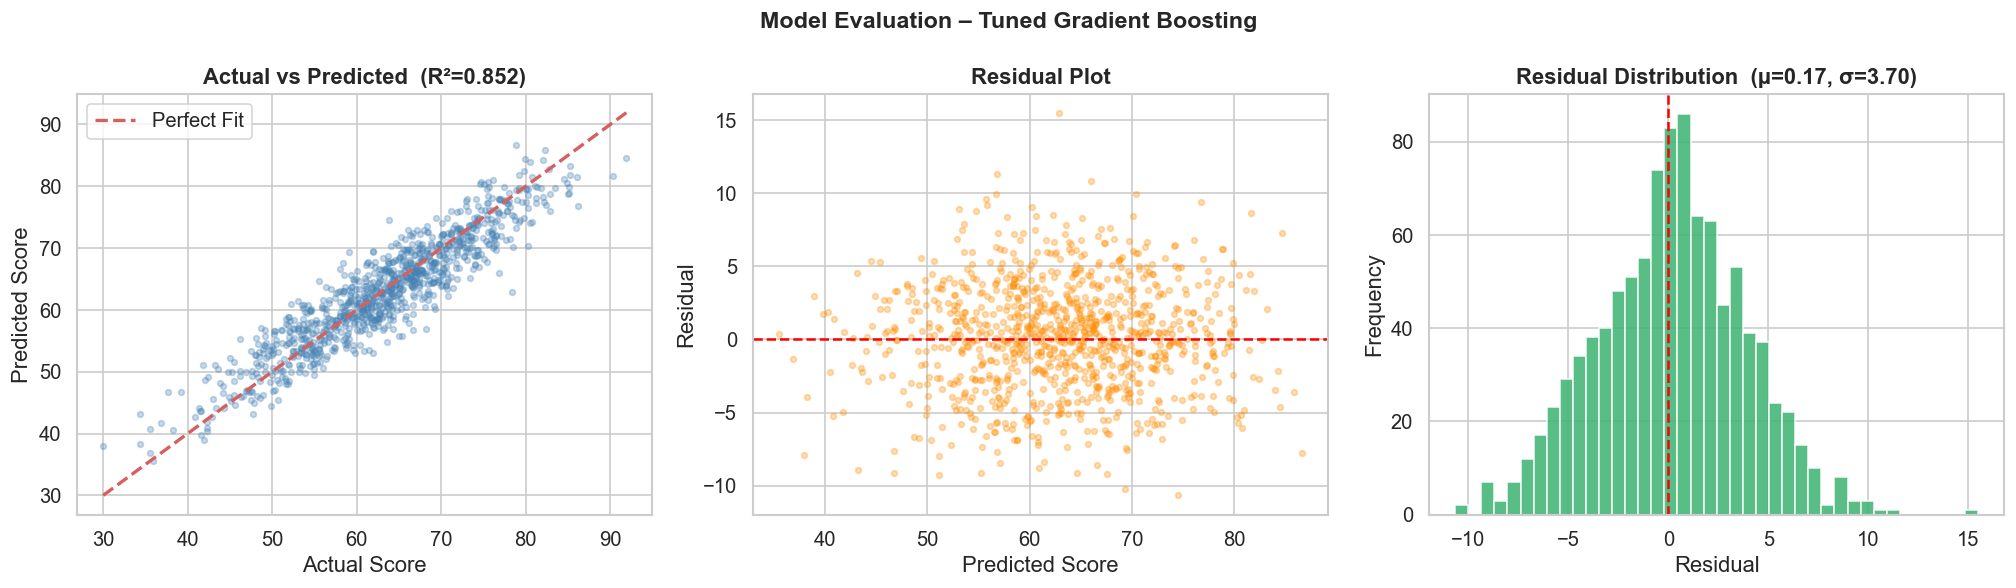

In [33]:
# ── Evaluation plots ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# 1. Actual vs Predicted
axes[0].scatter(y_test, y_pred_best, alpha=0.3, s=12, color='steelblue')
lims = [min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())]
axes[0].plot(lims, lims, 'r--', linewidth=2, label='Perfect Fit')
axes[0].set_xlabel('Actual Score')
axes[0].set_ylabel('Predicted Score')
axes[0].set_title(f'Actual vs Predicted  (R²={r2_score(y_test,y_pred_best):.3f})')
axes[0].legend()

# 2. Residuals
residuals = y_test - y_pred_best
axes[1].scatter(y_pred_best, residuals, alpha=0.3, s=12, color='darkorange')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Predicted Score')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residual Plot')

# 3. Residual histogram
axes[2].hist(residuals, bins=40, color='mediumseagreen', edgecolor='white', alpha=0.85)
axes[2].axvline(0, color='red', linestyle='--')
axes[2].set_xlabel('Residual')
axes[2].set_ylabel('Frequency')
axes[2].set_title(f'Residual Distribution  (μ={residuals.mean():.2f}, σ={residuals.std():.2f})')

plt.suptitle('Model Evaluation – Tuned Gradient Boosting', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_model_evaluation.png', bbox_inches='tight')
plt.show()

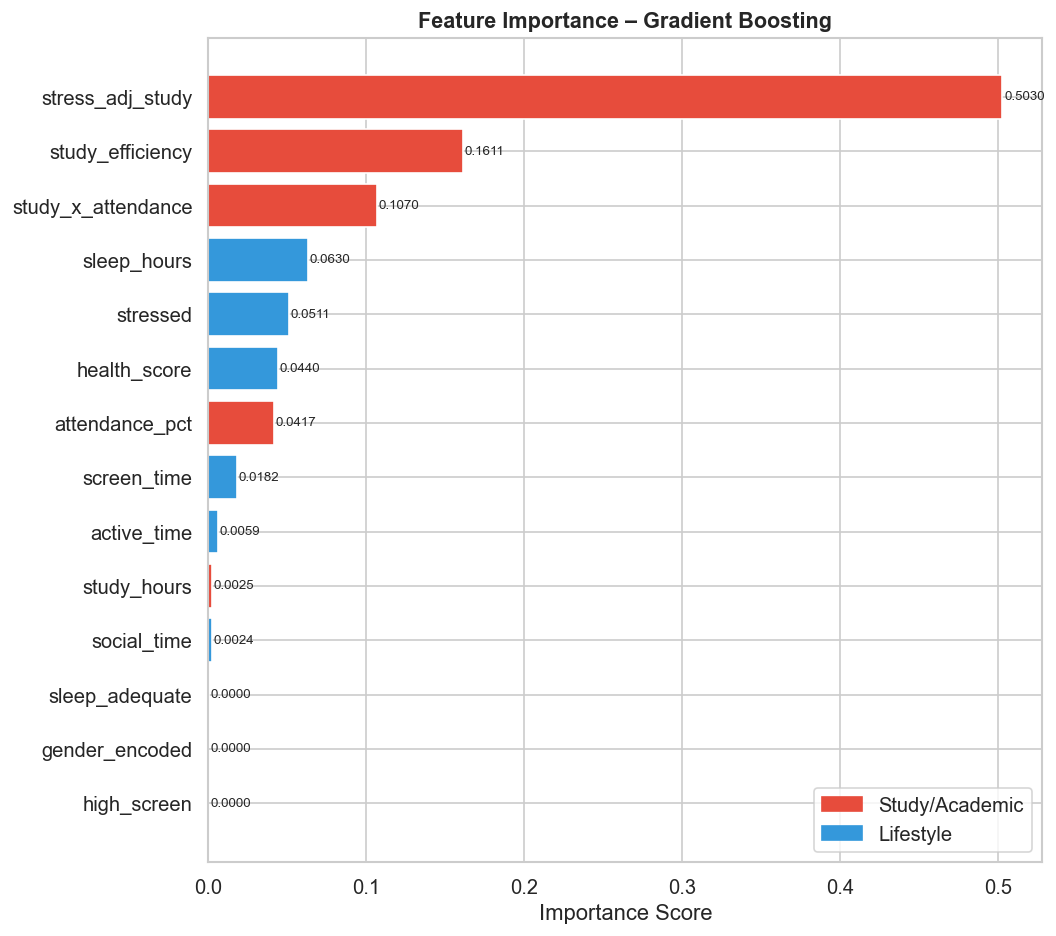

In [34]:
# ── Feature importance ────────────────────────────────────────────────────────
importance = pd.Series(best_model.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 8))
colors = ['#e74c3c' if f in ['study_hours','attendance_pct','study_x_attendance',
                               'study_efficiency','stress_adj_study']
          else '#3498db' for f in importance.index]
ax.barh(importance.index, importance.values, color=colors)
ax.set_title('Feature Importance – Gradient Boosting', fontsize=13)
ax.set_xlabel('Importance Score')
for i, v in enumerate(importance.values):
    ax.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=8)
red_p  = mpatches.Patch(color='#e74c3c', label='Study/Academic')
blue_p = mpatches.Patch(color='#3498db', label='Lifestyle')
ax.legend(handles=[red_p, blue_p])
plt.tight_layout()
plt.savefig('plot_feature_importance.png', bbox_inches='tight')
plt.show()

In [35]:
# ── Save model & scaler ───────────────────────────────────────────────────────
model_package = {
    'model':    best_model,
    'scaler':   scaler,
    'features': FEATURES,
    'metadata': {
        'r2':  r2_score(y_test, y_pred_best),
        'mae': mean_absolute_error(y_test, y_pred_best),
        'rmse': np.sqrt(mean_squared_error(y_test, y_pred_best))
    }
}
with open('scoresense_model.pkl', 'wb') as f:
    pickle.dump(model_package, f)
print('✅ Model saved to scoresense_model.pkl')

✅ Model saved to scoresense_model.pkl


---
## 🔮 Section 8 – Prediction System

In [36]:
def predict_score(student_data: dict) -> dict:
    """
    Predict exam score for a single student.

    Accepts the MERGED input format used after preprocessing:
      screen_time  = mobile + tv combined
      active_time  = exercise + extracurricular combined
      social_time  = friends + family combined
      stressed     = 'Yes' or 'No'
      gender       = 'Male' or 'Female'

    Returns dict: predicted_score, grade, confidence_interval
    """
    d = student_data.copy()

    # -- Encode categorical inputs -------------------------------------------
    d['gender_encoded'] = 1 if d.get('gender', 'Male') == 'Male' else 0
    d['stressed']       = 1 if d.get('stressed', 'No') == 'Yes' else 0

    # -- Sub-estimates from merged totals ------------------------------------
    exercise_est = d['active_time'] * 0.60

    # -- Engineered features (mirrors Cell 19 exactly) -----------------------
    d['study_efficiency']   = d['study_hours'] / (d['screen_time'] + 1)
    d['health_score']       = (
        d['sleep_hours'] / 8
        + exercise_est   / 2
        - d['stressed']  * 0.4
    ) / 3 * 100
    d['sleep_adequate']     = int(d['sleep_hours'] >= 7)
    d['high_screen']        = int(d['screen_time'] > 5)
    d['study_x_attendance'] = d['study_hours'] * d['attendance_pct'] / 100
    d['stress_adj_study']   = d['study_hours'] * (1 - d['stressed'] * 0.25)

    # -- Build feature row and predict ---------------------------------------
    row   = pd.DataFrame([[d[f] for f in FEATURES]], columns=FEATURES)
    score = float(best_model.predict(row)[0])
    score = max(30.0, min(100.0, score))

    rmse  = model_package['metadata']['rmse']
    ci_lo = max(0,   round(score - 1.96 * rmse, 2))
    ci_hi = min(100, round(score + 1.96 * rmse, 2))

    return {
        'predicted_score':     round(score, 2),
        'grade':               grade_category(score),
        'confidence_interval': (ci_lo, ci_hi)
    }


# -- Demo students using MERGED input format ---------------------------------
students = {
    'High Performer': {
        'sleep_hours':   8.0,
        'study_hours':   7.0,
        'screen_time':   1.5,   # mobile(0.9) + tv(0.6)
        'active_time':   4.0,   # exercise(2.4) + extra(1.6)
        'social_time':   3.5,   # friends(1.75) + family(1.75)
        'attendance_pct': 95.0,
        'stressed':      'No',
        'gender':        'Female'
    },
    'Average Student': {
        'sleep_hours':   7.0,
        'study_hours':   4.0,
        'screen_time':   5.5,   # mobile(3.3) + tv(2.2)
        'active_time':   2.0,   # exercise(1.2) + extra(0.8)
        'social_time':   4.5,   # friends(2.25) + family(2.25)
        'attendance_pct': 78.0,
        'stressed':      'No',
        'gender':        'Male'
    },
    'Struggling Student': {
        'sleep_hours':   5.5,
        'study_hours':   1.5,
        'screen_time':   9.5,   # mobile(5.7) + tv(3.8)
        'active_time':   0.5,   # exercise(0.3) + extra(0.2)
        'social_time':   5.0,   # friends(2.5) + family(2.5)
        'attendance_pct': 55.0,
        'stressed':      'Yes',
        'gender':        'Male'
    }
}

print('=' * 62)
print('  SCORESENSE AI -- PREDICTION RESULTS')
print('=' * 62)
for name, data in students.items():
    result = predict_score(data)
    print(f"\n  {name}")
    print(f"    Predicted Score : {result['predicted_score']}")
    print(f"    Grade           : {result['grade']}")
    print(f"    95% CI          : {result['confidence_interval']}")


  SCORESENSE AI -- PREDICTION RESULTS

  High Performer
    Predicted Score : 90.75
    Grade           : A (Excellent)
    95% CI          : (np.float64(83.49), np.float64(98.01))

  Average Student
    Predicted Score : 64.35
    Grade           : C (Average)
    95% CI          : (np.float64(57.1), np.float64(71.61))

  Struggling Student
    Predicted Score : 34.65
    Grade           : F (Fail)
    95% CI          : (np.float64(27.39), np.float64(41.9))


---
## 💡 Section 9 – Personalized Recommendation Engine

In [37]:
# Benchmarks from top-quartile students using MERGED column names
top_quartile = df_processed[
    df_processed['exam_score'] >= df_processed['exam_score'].quantile(0.75)
]
BENCHMARKS = top_quartile[[
    'study_hours', 'sleep_hours', 'screen_time',
    'active_time', 'social_time', 'attendance_pct'
]].mean().round(2)
BENCHMARKS['stressed'] = 0   # top students are mostly not stressed

print('Top-Quartile Benchmarks (merged features):')
print(BENCHMARKS)


def generate_recommendations(student_data: dict) -> dict:
    """
    Generate personalised recommendations via gap analysis.
    Accepts the same MERGED input dict as predict_score().
    """
    pred  = predict_score(student_data)
    score = pred['predicted_score']
    grade = pred['grade']
    recs  = []
    tips  = []
    d     = student_data

    # Sub-estimates for display
    mobile_est   = round(d['screen_time'] * 0.60, 1)
    tv_est       = round(d['screen_time'] * 0.40, 1)
    exercise_est = round(d['active_time'] * 0.60, 1)
    extra_est    = round(d['active_time'] * 0.40, 1)

    # 1. Study hours
    gap = BENCHMARKS['study_hours'] - d['study_hours']
    if gap > 0.5:
        recs.append({
            'category': 'Study Hours',
            'current':  d['study_hours'],
            'target':   BENCHMARKS['study_hours'],
            'message':  f"Increase by {gap:.1f}h/day. Use the Pomodoro technique (25-min focused blocks).",
            'impact':   0.40
        })

    # 2. Sleep
    if d['sleep_hours'] < 7:
        recs.append({
            'category': 'Sleep Quality',
            'current':  d['sleep_hours'],
            'target':   7.5,
            'message':  f"Aim for 7-9 hrs. Poor sleep reduces memory consolidation. Gain {7 - d['sleep_hours']:.1f}h more.",
            'impact':   0.20
        })
    elif d['sleep_hours'] > 9.5:
        recs.append({
            'category': 'Sleep Quality',
            'current':  d['sleep_hours'],
            'target':   8.0,
            'message':  'Oversleeping reduces alertness. Target 7-9 hours.',
            'impact':   0.10
        })

    # 3. Screen time
    if d['screen_time'] > BENCHMARKS['screen_time'] + 0.8:
        excess = d['screen_time'] - BENCHMARKS['screen_time']
        recs.append({
            'category': 'Screen Time',
            'current':  d['screen_time'],
            'target':   BENCHMARKS['screen_time'],
            'message':  (f"Total screen {d['screen_time']:.1f}h (~{mobile_est}h mobile + ~{tv_est}h TV). "
                         f"Reduce by {excess:.1f}h. Enable app timers."),
            'impact':   0.15
        })

    # 4. Attendance
    if d['attendance_pct'] < BENCHMARKS['attendance_pct'] - 5:
        recs.append({
            'category': 'Attendance',
            'current':  d['attendance_pct'],
            'target':   BENCHMARKS['attendance_pct'],
            'message':  (f"Your attendance is {d['attendance_pct']:.0f}%. "
                         f"Top students average {BENCHMARKS['attendance_pct']:.0f}%. "
                         "Missing class creates gaps hard to recover."),
            'impact':   0.18
        })

    # 5. Active time
    if d['active_time'] < BENCHMARKS['active_time'] - 0.4:
        recs.append({
            'category': 'Active Time',
            'current':  d['active_time'],
            'target':   BENCHMARKS['active_time'],
            'message':  (f"Active time {d['active_time']:.1f}h (~{exercise_est}h exercise + ~{extra_est}h extra). "
                         "Exercise boosts cognition; extracurriculars reduce burnout."),
            'impact':   0.08
        })

    # 6. Stress
    if d.get('stressed') == 'Yes':
        recs.append({
            'category': 'Stress Management',
            'current':  'Yes',
            'target':   'No',
            'message':  ('High stress impairs memory. Try: time-blocking, '
                         '10-min meditation, breaking tasks into small goals.'),
            'impact':   0.12
        })

    recs.sort(key=lambda x: x['impact'], reverse=True)

    if not recs:
        tips.append('Great habits! Maintain consistency and consider peer tutoring.')

    return {
        'predicted_score':     score,
        'grade':               grade,
        'confidence_interval': pred['confidence_interval'],
        'recommendations':     recs,
        'general_tips':        tips
    }


print('Recommendation engine ready!')


Top-Quartile Benchmarks (merged features):
study_hours        5.85
sleep_hours        7.35
screen_time        5.03
active_time        2.88
social_time        4.46
attendance_pct    81.70
stressed           0.00
dtype: float64
Recommendation engine ready!


In [38]:
# ── Demo: recommendations for Struggling Student ──────────────────────────────
target_student = students['Struggling Student']
report = generate_recommendations(target_student)

print('='*65)
print('  ✨ SCORESENSE AI – PERSONALIZED IMPROVEMENT REPORT')
print('='*65)
print(f"  Predicted Score : {report['predicted_score']}")
print(f"  Grade           : {report['grade']}")
print(f"  95% CI          : {report['confidence_interval']}")
print()
print('  📌 RECOMMENDATIONS (ranked by impact):')
print('-'*65)
for i, rec in enumerate(report['recommendations'], 1):
    print(f"  {i}. {rec['category']}")
    print(f"     Current: {rec['current']}  →  Target: {rec['target']}  (Impact: {rec['impact']:.0%})")
    print(f"     💬 {rec['message']}")
    print()

if report['general_tips']:
    for tip in report['general_tips']:
        print(f'  {tip}')

  ✨ SCORESENSE AI – PERSONALIZED IMPROVEMENT REPORT
  Predicted Score : 34.65
  Grade           : F (Fail)
  95% CI          : (np.float64(27.39), np.float64(41.9))

  📌 RECOMMENDATIONS (ranked by impact):
-----------------------------------------------------------------
  1. Study Hours
     Current: 1.5  →  Target: 5.85  (Impact: 40%)
     💬 Increase by 4.3h/day. Use the Pomodoro technique (25-min focused blocks).

  2. Sleep Quality
     Current: 5.5  →  Target: 7.5  (Impact: 20%)
     💬 Aim for 7-9 hrs. Poor sleep reduces memory consolidation. Gain 1.5h more.

  3. Attendance
     Current: 55.0  →  Target: 81.7  (Impact: 18%)
     💬 Your attendance is 55%. Top students average 82%. Missing class creates gaps hard to recover.

  4. Screen Time
     Current: 9.5  →  Target: 5.03  (Impact: 15%)
     💬 Total screen 9.5h (~5.7h mobile + ~3.8h TV). Reduce by 4.5h. Enable app timers.

  5. Stress Management
     Current: Yes  →  Target: No  (Impact: 12%)
     💬 High stress impairs memory.

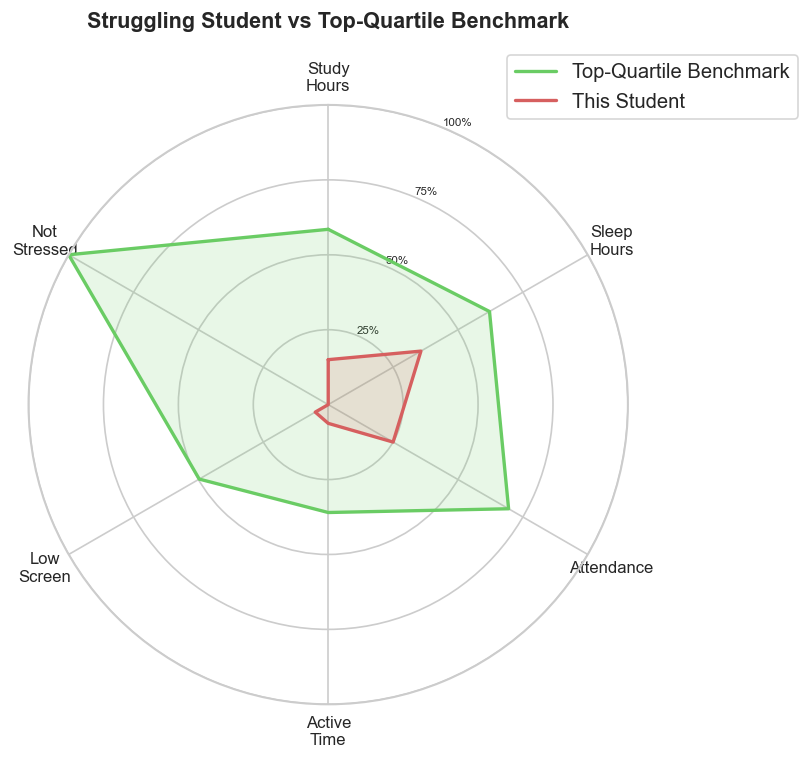

In [39]:
def radar_chart(student_data, title='Student vs Benchmark'):
    """Radar chart using merged feature set."""
    d          = student_data
    stressed_n = 1 if d.get('stressed') == 'Yes' else 0
    categories = ['Study\nHours', 'Sleep\nHours', 'Attendance',
                  'Active\nTime', 'Low\nScreen', 'Not\nStressed']

    def norm(val, lo, hi):
        return max(0.0, min(1.0, (val - lo) / (hi - lo)))

    student_vals = [
        norm(d['study_hours'],          0,  10),
        norm(d['sleep_hours'],          3,  10),
        norm(d['attendance_pct'],      40, 100),
        norm(d['active_time'],          0,   8),
        norm(12 - d['screen_time'],     2,  12),
        norm(1 - stressed_n,            0,   1),
    ]
    bench_vals = [
        norm(BENCHMARKS['study_hours'],    0,  10),
        norm(BENCHMARKS['sleep_hours'],    3,  10),
        norm(BENCHMARKS['attendance_pct'],40, 100),
        norm(BENCHMARKS['active_time'],    0,   8),
        norm(12 - BENCHMARKS['screen_time'], 2, 12),
        1.0,   # top students: not stressed
    ]

    N      = len(categories)
    angles = [n / float(N) * 2 * np.pi for n in range(N)] + [0]
    student_vals += [student_vals[0]]
    bench_vals   += [bench_vals[0]]

    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=10)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['25%', '50%', '75%', '100%'], fontsize=7)
    ax.plot(angles, bench_vals,   'g-', linewidth=2, label='Top-Quartile Benchmark')
    ax.fill(angles, bench_vals,   'g',  alpha=0.15)
    ax.plot(angles, student_vals, 'r-', linewidth=2, label='This Student')
    ax.fill(angles, student_vals, 'r',  alpha=0.15)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.tight_layout()
    plt.savefig('plot_radar_chart.png', bbox_inches='tight')
    plt.show()


radar_chart(students['Struggling Student'],
            title='Struggling Student vs Top-Quartile Benchmark')


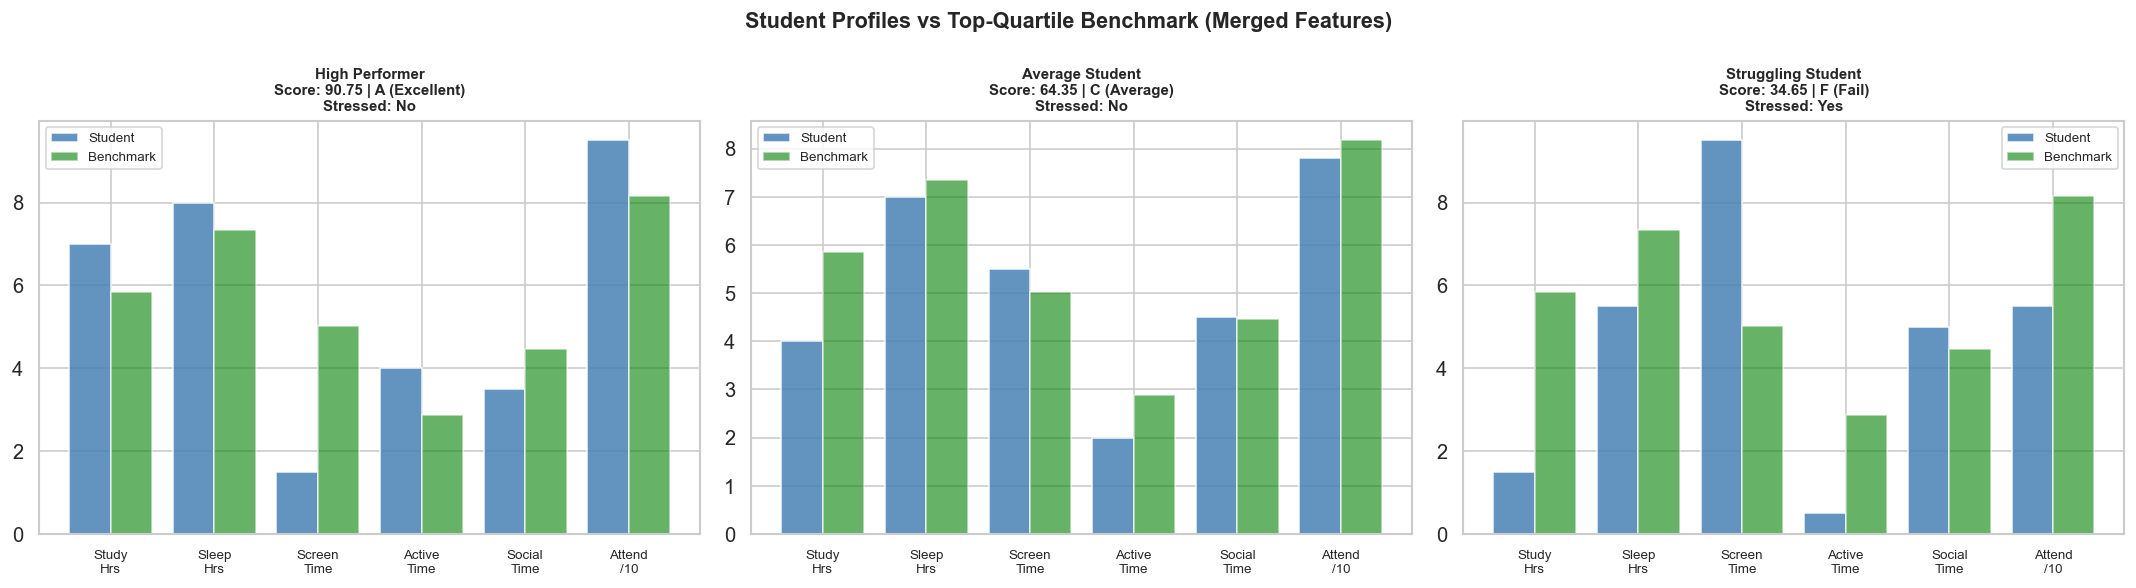

In [40]:
# Compare all three demo students using MERGED feature labels
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
feature_labels = ['Study\nHrs', 'Sleep\nHrs', 'Screen\nTime',
                   'Active\nTime', 'Social\nTime', 'Attend\n/10']

for ax, (name, data) in zip(axes, students.items()):
    vals = [
        data['study_hours'],
        data['sleep_hours'],
        data['screen_time'],
        data['active_time'],
        data['social_time'],
        data['attendance_pct'] / 10
    ]
    bench = [
        BENCHMARKS['study_hours'],
        BENCHMARKS['sleep_hours'],
        BENCHMARKS['screen_time'],
        BENCHMARKS['active_time'],
        BENCHMARKS['social_time'],
        BENCHMARKS['attendance_pct'] / 10
    ]
    x = np.arange(len(vals))
    ax.bar(x - 0.2, vals,  0.4, label='Student',   color='steelblue', alpha=0.85)
    ax.bar(x + 0.2, bench, 0.4, label='Benchmark', color='green',     alpha=0.60)
    ax.set_xticks(x)
    ax.set_xticklabels(feature_labels, fontsize=8)
    res = predict_score(data)
    stressed_label = data.get('stressed', 'No')
    ax.set_title(
        f"{name}\nScore: {res['predicted_score']} | {res['grade']}\nStressed: {stressed_label}",
        fontsize=9
    )
    ax.legend(fontsize=8)

plt.suptitle('Student Profiles vs Top-Quartile Benchmark (Merged Features)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_student_profiles.png', bbox_inches='tight')
plt.show()


---
## 🌐 Section 10 – Streamlit Web Interface

Save the code below as **`app.py`** and run:
```bash
pip install streamlit
streamlit run app.py
```

In [ ]:
# Redesigned Streamlit App - Save as app.py and run: streamlit run app.py
# All features properly wired to the trained model
app_source = '''# -*- coding: utf-8 -*-
# ============================================================
#  ScoreSense AI  -  Premium Aurora Edition
#  Run: streamlit run premium_app.py
# ============================================================
import streamlit as st
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

st.set_page_config(
    page_title="ScoreSense AI | Premium",
    page_icon="✨",
    layout="wide",
    initial_sidebar_state="expanded"
)

# ============================================================
#  AURORA GLASS CSS
# ============================================================
st.markdown("""
<style>
  @import url('https://fonts.googleapis.com/css2?family=Outfit:wght@300;400;500;700;800&family=DM+Sans:wght@400;500;700&family=JetBrains+Mono:wght@400;500&display=swap');

  :root {
    --aurora-1: #6E44FF;
    --aurora-2: #0DE2EA;
    --aurora-3: #F9A03F;
    --bg-dark: #07070B;
    --panel-bg: rgba(20, 20, 35, 0.5);
    --sidebar-bg: rgba(12, 12, 18, 0.85);
    --border-light: rgba(255, 255, 255, 0.08);
    --glass-blur: blur(24px);
    --text-main: #FFFFFF;
    --text-muted: #9CA3AF;
  }

  /* Core App Overrides */
  [data-testid="stAppViewContainer"] {
    background-color: var(--bg-dark);
    background-image: 
      radial-gradient(circle at 10% 20%, rgba(110, 68, 255, 0.15) 0%, transparent 40%),
      radial-gradient(circle at 90% 40%, rgba(13, 226, 234, 0.15) 0%, transparent 40%),
      radial-gradient(circle at 50% 90%, rgba(249, 160, 63, 0.1) 0%, transparent 50%);
    background-attachment: fixed;
    color: var(--text-main);
    font-family: 'DM Sans', sans-serif;
  }
  
  [data-testid="stSidebar"] {
    background-color: var(--sidebar-bg) !important;
    backdrop-filter: var(--glass-blur);
    border-right: 1px solid var(--border-light);
  }

  h1, h2, h3, h4 { font-family: 'Outfit', sans-serif !important; }

  /* Premium Header Elements */
  .premium-header {
    margin-top: 10px;
    margin-bottom: 40px;
    padding: 40px;
    border-radius: 24px;
    background: var(--panel-bg);
    backdrop-filter: var(--glass-blur);
    border: 1px solid var(--border-light);
    box-shadow: 0 10px 40px rgba(0,0,0,0.5);
    position: relative;
    overflow: hidden;
  }
  .premium-header::after {
    content: ''; position: absolute; top: 0; left: 0; right: 0; height: 1px;
    background: linear-gradient(90deg, transparent, rgba(255,255,255,0.3), transparent);
  }
  .title-glow {
    font-family: 'Outfit', sans-serif;
    font-size: 3.5rem;
    font-weight: 800;
    margin: 0;
    background: linear-gradient(90deg, #FFFFFF, var(--aurora-2));
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
    letter-spacing: -0.02em;
  }
  .subtitle {
    font-size: 1.1rem;
    color: var(--text-muted);
    font-weight: 400;
    margin-top: 5px;
  }
  
  /* Circle Gauge SVG */
  .gauge-container { display: flex; justify-content: center; align-items: center; margin: 30px 0; }
  .gauge-svg { width: 280px; height: 280px; transform: rotate(-90deg); filter: drop-shadow(0 0 20px rgba(0,0,0,0.5)); }
  .gauge-track { fill: none; stroke: rgba(255,255,255,0.05); stroke-width: 12; }
  .gauge-fill {
    fill: none; stroke-width: 12; stroke-linecap: round;
    transition: stroke-dasharray 1.5s cubic-bezier(0.4, 0, 0.2, 1);
  }
  .gauge-text-val {
    font-family: 'Outfit'; font-size: 4rem; font-weight: 800; fill: #fff;
    transform: rotate(90deg); transform-origin: center; dominant-baseline: middle; text-anchor: middle;
  }
  .gauge-text-lbl {
    font-family: 'DM Sans'; font-size: 1rem; fill: var(--text-muted); font-weight: 600; text-transform: uppercase; letter-spacing: 0.1em;
    transform: rotate(90deg) translate(0, 45px); transform-origin: center; dominant-baseline: middle; text-anchor: middle;
  }
  
  /* Feature Cards */
  .feature-card {
    background: var(--panel-bg);
    backdrop-filter: var(--glass-blur);
    border: 1px solid var(--border-light);
    border-radius: 16px;
    padding: 24px;
    margin-bottom: 20px;
    transition: all 0.3s ease;
    position: relative;
    overflow: hidden;
  }
  .feature-card:hover { transform: translateY(-5px); border-color: rgba(255,255,255,0.2); box-shadow: 0 15px 30px rgba(0,0,0,0.4); }
  .fc-icon { font-size: 2rem; margin-bottom: 12px; }
  .fc-title { font-family: 'Outfit'; font-weight: 700; font-size: 1.1rem; color: #fff; margin-bottom: 6px; }
  .fc-desc { font-size: 0.9rem; color: var(--text-muted); line-height: 1.5; }
  .fc-impact { position: absolute; top: 20px; right: 20px; background: rgba(255,255,255,0.1); padding: 4px 10px; border-radius: 12px; font-family: 'JetBrains Mono'; font-size: 0.75rem; color: #fff; font-weight: 600; }

  /* Generic UI components overrides */
  div[data-testid="stSlider"] > div > div > div > div { background: linear-gradient(90deg, var(--aurora-1), var(--aurora-2)) !important; }
  div[data-testid="stButton"] > button[kind="primary"] {
    background: linear-gradient(135deg, var(--aurora-1), var(--aurora-2)) !important;
    border: none !important; color: white !important; font-family: 'Outfit' !important; font-weight: 700 !important;
    font-size: 1.1rem !important; padding: 24px !important; border-radius: 16px !important;
    box-shadow: 0 8px 25px rgba(13, 226, 234, 0.3) !important; transition: all 0.3s ease !important;
  }
  div[data-testid="stButton"] > button[kind="primary"]:hover { transform: scale(1.02) !important; box-shadow: 0 12px 35px rgba(13, 226, 234, 0.5) !important; }

  #MainMenu, footer { visibility: hidden; }
  header { background-color: transparent !important; }
</style>
""", unsafe_allow_html=True)


# ============================================================
#  MODEL CONFIGURATION
# ============================================================
@st.cache_resource
def load_model():
    with open("scoresense_model.pkl", "rb") as f:
        return pickle.load(f)

try:
    pkg      = load_model()
    model    = pkg["model"]
    FEATURES = pkg["features"]
except FileNotFoundError:
    st.error("scoresense_model.pkl not found. Please train the model first.")
    st.stop()

BENCHMARKS = {
    "study_hours":    5.8, "sleep_hours":    7.4, "screen_time":    3.9,
    "active_time":    3.3, "social_time":    4.2, "attendance_pct": 87.0,
    "stressed":       0,
}

GRADE_CONFIG = {
    "A (Excellent)": {"color": "#0DE2EA", "glow": "rgba(13,226,234,0.6)", "emoji": "🏆", "msg": "Elite Performance"},
    "B (Good)":      {"color": "#6E44FF", "glow": "rgba(110,68,255,0.6)", "emoji": "👍", "msg": "Strong Trajectory"},
    "C (Average)":   {"color": "#F9A03F", "glow": "rgba(249,160,63,0.6)", "emoji": "📘", "msg": "Baseline Operation"},
    "D (Below Avg)": {"color": "#EF4444", "glow": "rgba(239,68,68,0.6)", "emoji": "⚠️", "msg": "Warning: Deviation"},
    "F (Fail)":      {"color": "#991B1B", "glow": "rgba(153,27,27,0.6)", "emoji": "❗", "msg": "System Critical"},
}

def grade_category(score):
    if score >= 85:   return "A (Excellent)"
    elif score >= 70: return "B (Good)"
    elif score >= 55: return "C (Average)"
    elif score >= 40: return "D (Below Avg)"
    else:             return "F (Fail)"

# ============================================================
#  FEATURE LOGIC
# ============================================================
def build_features(d: dict):
    screen_time  = d["screen_time"]
    active_time  = d["active_time"]
    social_time  = d["social_time"]
    stressed_bin = 1 if d["stressed"] == "Yes" else 0
    gender_enc   = 1 if d["gender"] == "Male" else 0
    study_hours  = d["study_hours"]
    sleep_hours  = d["sleep_hours"]
    attendance   = d["attendance_pct"]

    mobile_est   = round(screen_time * 0.60, 1)
    tv_est       = round(screen_time * 0.40, 1)
    exercise_est = round(active_time * 0.60, 1)
    extra_est    = round(active_time * 0.40, 1)

    study_efficiency   = study_hours / (screen_time + 1)
    health_score       = (sleep_hours / 8 + exercise_est / 2 - stressed_bin * 0.4) / 3 * 100
    sleep_adequate     = int(sleep_hours >= 7)
    high_screen        = int(screen_time > 5)
    study_x_attendance = study_hours * attendance / 100
    stress_adj_study   = study_hours * (1 - stressed_bin * 0.25)

    feature_map = {
        "sleep_hours": sleep_hours, "study_hours": study_hours,
        "screen_time": screen_time, "active_time": active_time,
        "social_time": social_time, "attendance_pct": attendance,
        "stressed": stressed_bin,   "gender_encoded": gender_enc,
        "study_efficiency": study_efficiency, "health_score": health_score,
        "sleep_adequate": sleep_adequate, "high_screen": high_screen,
        "study_x_attendance": study_x_attendance, "stress_adj_study": stress_adj_study,
    }
    row = pd.DataFrame([[feature_map[f] for f in FEATURES]], columns=FEATURES)
    expanded = {"mobile_est": mobile_est, "tv_est": tv_est, "exercise_est": exercise_est, "extra_est": extra_est}
    return row, expanded

def predict(d: dict):
    row, expanded = build_features(d)
    score = float(model.predict(row)[0])
    score = max(30.0, min(100.0, score))
    return round(score, 2), grade_category(score), expanded

def make_recommendations(d: dict, expanded: dict):
    recs = []
    gap = BENCHMARKS["study_hours"] - d["study_hours"]
    if gap > 0.5:
        recs.append({"title": "Neural Focus Protocol", "detail": f"Increase focus output to {BENCHMARKS['study_hours']:.1f}h/day. Add {gap:.1f}h using intensive Pomodoro sessions.", "impact": 0.40, "icon": "🧠"})
    if d["sleep_hours"] < 7:
        recs.append({"title": "Regenerative Cycle Alert", "detail": f"Current cycle: {d['sleep_hours']:.1f}h. Sub-optimal. Aim for 7-9h to maximize memory consolidation.", "impact": 0.20, "icon": "🛌"})
    elif d["sleep_hours"] > 9.5:
        recs.append({"title": "Oversleep Warning", "detail": "Extended stasis detected. Reduce below 9h to prevent grogginess and cognitive lag.", "impact": 0.10, "icon": "🛌"})
    if d["screen_time"] > BENCHMARKS["screen_time"] + 0.8:
        excess = d["screen_time"] - BENCHMARKS["screen_time"]
        recs.append({"title": "Digital Detoxification", "detail": f"High digital saturation detected (~{d['screen_time']:.1f}h). Reduce by {excess:.1f}h. Initiate app limits.", "impact": 0.15, "icon": "📵"})
    if d["attendance_pct"] < BENCHMARKS["attendance_pct"] - 5:
        recs.append({"title": "Presence Calibration", "detail": f"Network attendance at {d['attendance_pct']:.0f}%. Target node connection rate: {BENCHMARKS['attendance_pct']:.0f}%.", "impact": 0.18, "icon": "📡"})
    if d["active_time"] < BENCHMARKS["active_time"] - 0.4:
        recs.append({"title": "Kinetic Optimization", "detail": f"Physical input low ({d['active_time']:.1f}h). Increase BDNF flow via kinetic activities.", "impact": 0.08, "icon": "⚡"})
    if d["stressed"] == "Yes":
        recs.append({"title": "Stress Response Purge", "detail": "High cortisol levels detected. Run meditation or decompression protocols to preserve hippocampal integrity.", "impact": 0.12, "icon": "🧘"})

    recs.sort(key=lambda x: x["impact"], reverse=True)
    return recs

# ============================================================
#  HOLOGRAPHIC RADAR CHART
# ============================================================
def holographic_radar_chart(d: dict):
    stressed_bin = 1 if d["stressed"] == "Yes" else 0
    categories = ["Study", "Sleep", "Class", "Active", "Digital\nDetox", "Zen"]
    def norm(val, lo, hi): return max(0.0, min(1.0, (val - lo) / (hi - lo)))

    cv = [
        norm(d["study_hours"], 0, 10), norm(d["sleep_hours"], 3, 10), norm(d["attendance_pct"], 40, 100),
        norm(d["active_time"], 0, 8), norm(12 - d["screen_time"], 2, 12), norm(1 - stressed_bin, 0, 1)
    ]
    HEALTHY = {
        "study_hours": min(d["study_hours"] + 1.5, 8.0), "sleep_hours": max(min(d["sleep_hours"], 9.0), 7.0),
        "attendance_pct": min(d["attendance_pct"] + 10, 95.0), "active_time": min(d["active_time"] + 1.0, 5.0),
        "screen_time": max(d["screen_time"] - 1.5, 2.0), "stressed": 0,
    }
    pv = [
        norm(HEALTHY["study_hours"], 0, 10), norm(HEALTHY["sleep_hours"], 3, 10), norm(HEALTHY["attendance_pct"], 40, 100),
        norm(HEALTHY["active_time"], 0, 8), norm(12 - HEALTHY["screen_time"], 2, 12), 1.0
    ]
    pv = [max(c, p) for c, p in zip(cv, pv)]

    N = len(categories)
    angles = [n / float(N) * 2 * np.pi for n in range(N)] + [0]
    cv += [cv[0]]; pv += [pv[0]]

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
    ax.set_facecolor('none')
    fig.patch.set_alpha(0.0)

    # Holographic Grids
    for r in [0.25, 0.5, 0.75, 1.0]:
        ax.plot(angles, [r]*(N+1), color="#0DE2EA", linewidth=0.5, alpha=0.3)
    for ang in angles[:-1]:
        ax.plot([ang, ang], [0, 1], color="#0DE2EA", linewidth=0.5, alpha=0.3)

    # Potential
    ax.fill(angles, pv, color="#6E44FF", alpha=0.1)
    ax.plot(angles, pv, color="#6E44FF", linewidth=2, linestyle='dotted')
    
    # Current
    ax.fill(angles, cv, color="#0DE2EA", alpha=0.25)
    ax.plot(angles, cv, color="#0DE2EA", linewidth=3)
    ax.scatter(angles[:-1], cv[:-1], color="#FFFFFF", s=50, edgecolors="#0DE2EA", zorder=10)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=10, color="#FFFFFF")
    ax.set_ylim(0, 1); ax.set_yticks([])
    ax.spines["polar"].set_visible(False)
    
    fig.tight_layout()
    return fig

# ============================================================
#  LAYOUT: SIDEBAR & MAIN AREA
# ============================================================
st.sidebar.markdown("""<div style="text-align:center; padding: 20px 0;"><h2 style="margin:0; font-family:'Outfit'; font-weight:800; background:linear-gradient(90deg,#fff,#0DE2EA); -webkit-background-clip:text; -webkit-text-fill-color:transparent;">SCORESENSE</h2><p style="color:#9CA3AF; letter-spacing:4px; font-size:0.7rem; text-transform:uppercase;">Input Matrix</p></div>""", unsafe_allow_html=True)
st.sidebar.markdown('---')

with st.sidebar:
    gender = st.selectbox("Operative Type (Gender)", ["Male", "Female"])
    study_hours = st.slider("Neural Focus (Study Hours)", 0.0, 12.0, 4.5, 0.5)
    sleep_hours = st.slider("Stasis Cycle (Sleep Hours)", 3.0, 12.0, 7.0, 0.5)
    screen_time = st.slider("Digital Saturation (Screen Time)", 0.0, 14.0, 5.5, 0.5)
    active_time = st.slider("Kinetic Output (Active Time)", 0.0, 10.0, 2.7, 0.5)
    social_time = st.slider("Network Bandwidth (Social Time)", 0.0, 12.0, 4.5, 0.5)
    attendance_pct = st.slider("Node Connection (Attendance %)", 40.0, 100.0, 78.0, 1.0)
    stressed = st.radio("Cortisol Overload? (Stress)", ["No", "Yes"], horizontal=True)
    st.markdown("<br>", unsafe_allow_html=True)
    predict_btn = st.button("INITIALIZE PREDICTION", width='stretch', type="primary")

# ============================================================
#  MAIN CANVAS
# ============================================================
st.markdown("""
<div class="premium-header">
  <div style="display:flex; justify-content:space-between; align-items:flex-end;">
    <div>
      <h1 class="title-glow">ScoreSense <i>Premium</i></h1>
      <div class="subtitle">Next-Generation Academic Prediction & Neural Optimization Model.</div>
    </div>
    <div style="font-family:'JetBrains Mono'; color:#0DE2EA; font-size:0.8rem; letter-spacing:0.1em; opacity:0.8; text-align:right;">
      MODEL STATUS: ONLINE<br>ALGORITHM: GRADIENT BOOSTING
    </div>
  </div>
</div>
""", unsafe_allow_html=True)

if not predict_btn:
    st.markdown("""
    <div style="text-align:center; margin-top:80px; animation: fadeUp 1s ease-out;">
      <h1 style="font-size:4rem; margin:0; opacity:0.8;">🌌</h1>
      <h3 style="color:#FFF; opacity:0.6; font-weight:400; margin-top:20px;">Awaiting Input Parameters...</h3>
      <p style="color:var(--text-muted); font-size:0.95rem;">Configure the matrix on the sidebar and press <strong style="color:var(--aurora-2)">INITIALIZE</strong>.</p>
    </div>
    """, unsafe_allow_html=True)

else:
    student = {"gender": gender, "study_hours": study_hours, "sleep_hours": sleep_hours, "screen_time": screen_time, "active_time": active_time, "social_time": social_time, "attendance_pct": attendance_pct, "stressed": stressed}
    score, grade, expanded = predict(student)
    cfg = GRADE_CONFIG[grade]
    
    circumference = 2 * np.pi * 130
    dash_offset = circumference - (score / 100.0) * circumference
    
    col1, col2 = st.columns([1, 1.3], gap="large")
    
    with col1:
        st.markdown(f"""
        <h3 style="margin-top:0; color:#fff;">Score Projection</h3>
        <p style="color:var(--text-muted); margin-bottom:20px;">Predicted examination outcome based on current parameters.</p>
        <div class="gauge-container" style="background:var(--panel-bg); backdrop-filter:var(--glass-blur); border:1px solid var(--border-light); border-radius:24px; padding:40px 0;">
          <svg class="gauge-svg" style="filter: drop-shadow(0 0 15px {cfg['glow']});">
            <circle class="gauge-track" cx="140" cy="140" r="130"></circle>
            <circle class="gauge-fill" cx="140" cy="140" r="130" stroke="{cfg['color']}" 
                    stroke-dasharray="{circumference}" stroke-dashoffset="{dash_offset}"></circle>
            <text class="gauge-text-val" x="140" y="140">{score}</text>
            <text class="gauge-text-lbl" x="140" y="140">{cfg['msg']} {cfg['emoji']}</text>
          </svg>
        </div>
        """, unsafe_allow_html=True)
        
        st.markdown('<br><h3 style="color:#fff;">Holographic Profile</h3>', unsafe_allow_html=True)
        st.pyplot(holographic_radar_chart(student), width="stretch")

    with col2:
        recs = make_recommendations(student, expanded)
        st.markdown(f'<h3 style="margin-top:0; color:#fff;">Actionable Protocols ({len(recs)})</h3>', unsafe_allow_html=True)
        st.markdown('<p style="color:var(--text-muted); margin-bottom:20px;">AI-derived instructions to reach maximum potential.</p>', unsafe_allow_html=True)
        
        if not recs:
            st.markdown("""<div class="feature-card" style="border-color:#0DE2EA; text-align:center;"><div class="fc-icon">🌟</div><div class="fc-title">Optimum Vector Reached</div><div class="fc-desc">Your parameters are flawlessly aligned. Maintain current operational logic to secure top performance over time.</div></div>""", unsafe_allow_html=True)
        else:
            for rec in recs:
                st.markdown(f"""
                <div class="feature-card">
                  <div class="fc-icon">{rec["icon"]}</div>
                  <div class="fc-title">{rec["title"]}</div>
                  <div class="fc-desc">{rec["detail"]}</div>
                  <div class="fc-impact">Yield: +{rec['impact']:.0%}</div>
                </div>
                """, unsafe_allow_html=True)'''

with open('app.py', 'w', encoding='utf-8') as f:
    f.write(app_source.lstrip('\n'))
print('app.py saved successfully!')
print('Run with: streamlit run app.py')


app.py saved successfully!
Run with: streamlit run app.py


---
## 📋 Section 11 – Project Summary & Key Insights

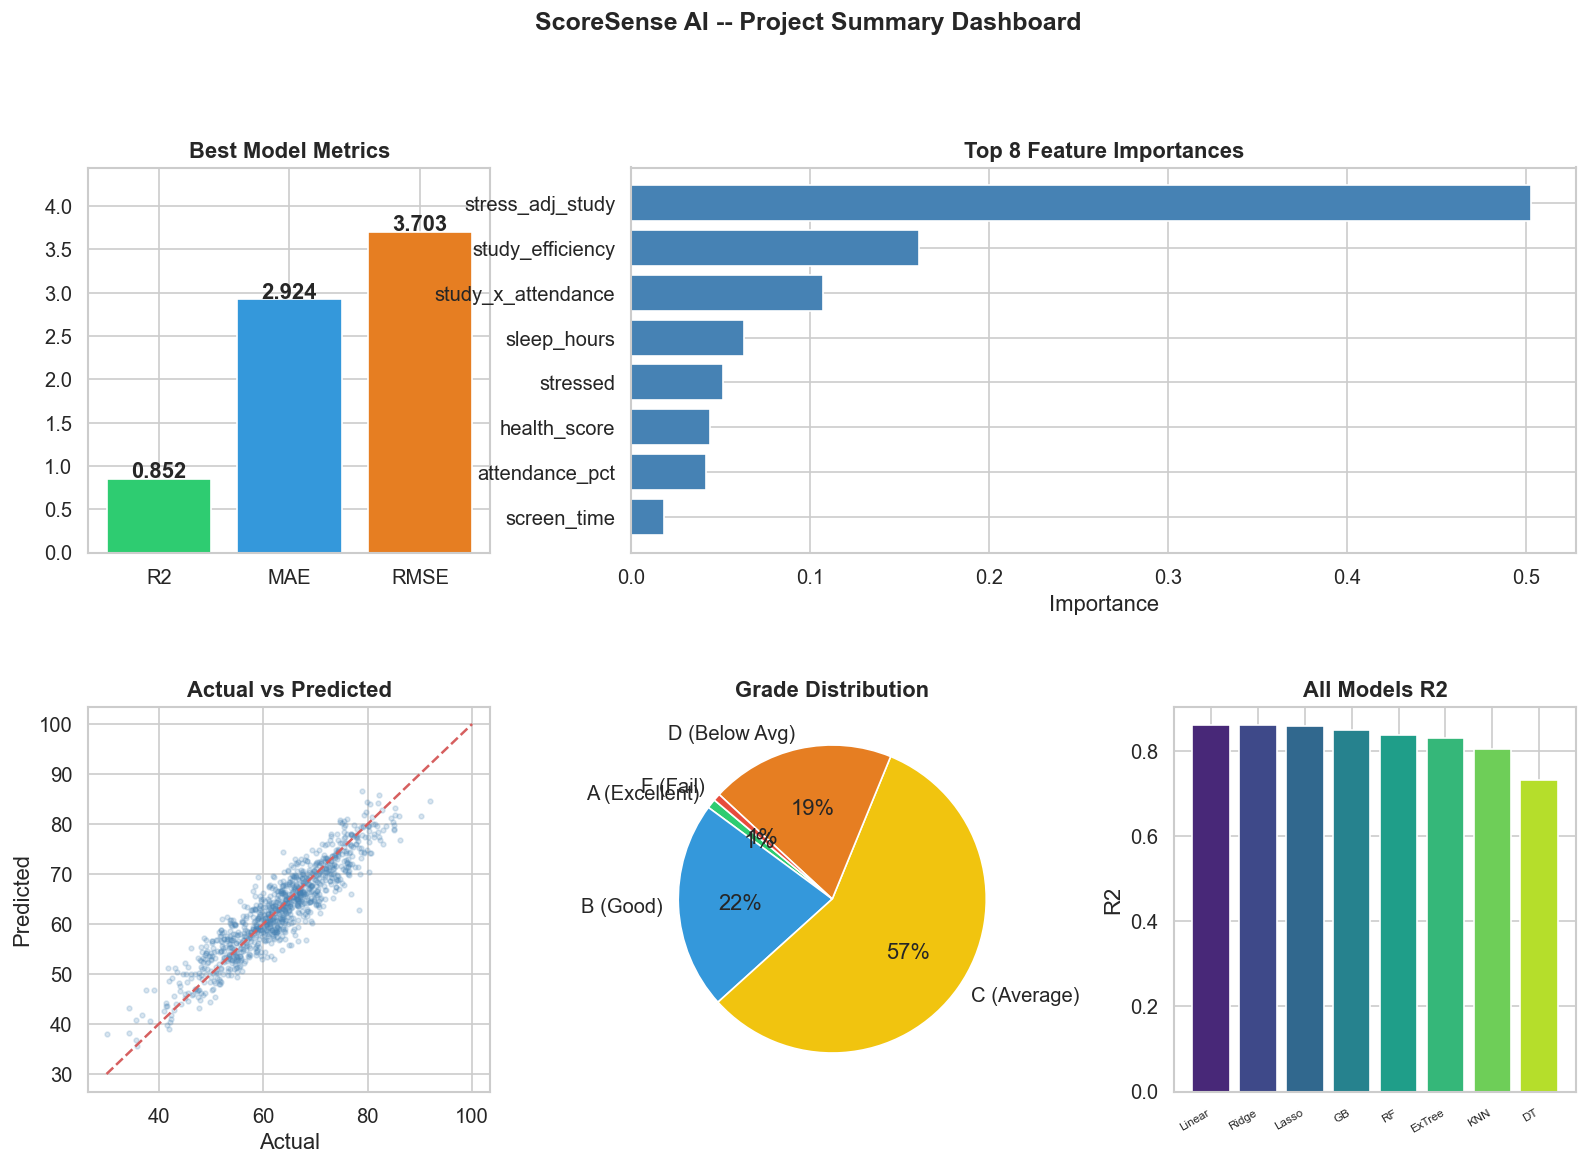


  SCORESENSE AI -- KEY FINDINGS
  Best Model : Gradient Boosting (tuned)
  R2         : 0.8523
  MAE        : 2.924 points
  RMSE       : 3.703 points
  MAPE       : 4.77%

  Top 3 Feature Importances:
    stress_adj_study               importance=0.5030
    study_efficiency               importance=0.1611
    study_x_attendance             importance=0.1070

  Files: scoresense_model.pkl | app.py | student_lifestyle_data.csv


In [ ]:
# Final summary dashboard
fig = plt.figure(figsize=(16, 10))
gs  = fig.add_gridspec(2, 3, hspace=0.4, wspace=0.35)

# 1. Model metrics bar chart
ax1 = fig.add_subplot(gs[0, 0])
metrics  = ['R2', 'MAE', 'RMSE']
values   = [r2_score(y_test, y_pred_best),
             mean_absolute_error(y_test, y_pred_best),
             np.sqrt(mean_squared_error(y_test, y_pred_best))]
colors_m = ['#2ecc71', '#3498db', '#e67e22']
bars = ax1.bar(metrics, values, color=colors_m, edgecolor='white')
for bar, val in zip(bars, values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', fontweight='bold')
ax1.set_title('Best Model Metrics')
ax1.set_ylim(0, max(values) * 1.2)

# 2. Feature importance (top 8)
ax2 = fig.add_subplot(gs[0, 1:])
top8 = importance.tail(8)
ax2.barh(top8.index, top8.values, color='steelblue')
ax2.set_title('Top 8 Feature Importances')
ax2.set_xlabel('Importance')

# 3. Actual vs Predicted
ax3 = fig.add_subplot(gs[1, 0])
ax3.scatter(y_test, y_pred_best, alpha=0.2, s=8, color='steelblue')
ax3.plot([30, 100], [30, 100], 'r--')
ax3.set_xlabel('Actual')
ax3.set_ylabel('Predicted')
ax3.set_title('Actual vs Predicted')

# 4. Grade distribution pie
ax4 = fig.add_subplot(gs[1, 1])
grade_order  = ['A (Excellent)', 'B (Good)', 'C (Average)', 'D (Below Avg)', 'F (Fail)']
grade_colors = ['#2ecc71', '#3498db', '#f1c40f', '#e67e22', '#e74c3c']
grade_counts = df_processed['grade'].value_counts().reindex(grade_order)
ax4.pie(grade_counts, labels=grade_order, colors=grade_colors,
        autopct='%1.0f%%', startangle=140)
ax4.set_title('Grade Distribution')

# 5. All model R2 comparison
ax5 = fig.add_subplot(gs[1, 2])
short_names = (results_df['Model']
               .str.replace(' Regression', '', regex=False)
               .str.replace('Gradient Boosting', 'GB', regex=False)
               .str.replace('Random Forest', 'RF', regex=False)
               .str.replace('Extra Trees', 'ExTree', regex=False)
               .str.replace('K-Nearest Neighbors', 'KNN', regex=False)
               .str.replace('Decision Tree', 'DT', regex=False))
ax5.bar(range(len(results_df)), results_df['R2'],
        color=sns.color_palette('viridis', len(results_df)))
ax5.set_xticks(range(len(results_df)))
ax5.set_xticklabels(short_names, fontsize=7, rotation=30, ha='right')
ax5.set_title('All Models R2')
ax5.set_ylabel('R2')

plt.suptitle('ScoreSense AI -- Project Summary Dashboard',
             fontsize=15, fontweight='bold', y=1.01)
plt.savefig('plot_summary_dashboard.png', bbox_inches='tight')
plt.show()

print()
print('=' * 65)
print('  SCORESENSE AI -- KEY FINDINGS')
print('=' * 65)
print(f'  Best Model : Gradient Boosting (tuned)')
print(f'  R2         : {r2_score(y_test, y_pred_best):.4f}')
print(f'  MAE        : {mean_absolute_error(y_test, y_pred_best):.3f} points')
print(f'  RMSE       : {np.sqrt(mean_squared_error(y_test, y_pred_best)):.3f} points')
print(f'  MAPE       : {mean_absolute_percentage_error(y_test, y_pred_best)*100:.2f}%')
print()
print('  Top 3 Feature Importances:')
top3 = importance.sort_values(ascending=False).head(3)
for feat, imp in top3.items():
    print(f'    {feat:<30} importance={imp:.4f}')
print()
print('  Files: scoresense_model.pkl | app.py | student_lifestyle_data.csv')
print('=' * 65)
